# Household Consumption and Expenditure Survey

: 

In [ ]:
# Table 1.1: Number of FSUs allotted and surveyed and number of households surveyed

In [ ]:
import pandas as pd

data = {
    "State_UT_All_India": ["Andhra Pradesh", "Arunachal Pradesh", "Assam", "Bihar", "Chhattisgarh", "Delhi", "Goa", "Gujarat", "Haryana", "Himachal Pradesh", "Jharkhand", "Karnataka", "Kerala", "Madhya Pradesh", "Maharashtra", "Manipur", "Meghalaya", "Mizoram", "Nagaland", "Odisha", "Punjab", "Rajasthan", "Sikkim", "Tamil Nadu", "Telangana", "Tripura", "Uttar Pradesh", "Uttarakhand", "West Bengal", "Andaman & Nicobar Islands", "Chandigarh", "Dadra & Nagar Haveli and Daman & Diu", "Jammu & Kashmir", "Ladakh", "Lakshadweep", "Puducherry"],
    "FSUs_Allotted_Rural": [361, 160, 341, 762, 160, 20, 20, 320, 160, 82, 221, 381, 220, 482, 660, 180, 120, 80, 120, 381, 180, 501, 80, 420, 200, 180, 1100, 100, 600, 40, 20, 20, 100, 20, 14, 20],
    "FSUs_Allotted_Urban": [240, 80, 140, 200, 120, 200, 20, 320, 140, 60, 140, 340, 200, 320, 660, 160, 60, 120, 60, 140, 160, 260, 40, 400, 180, 100, 600, 60, 420, 20, 20, 20, 100, 20, 20, 40],
    "FSUs_Surveyed_Rural": [360, 160, 337, 759, 160, 20, 20, 320, 155, 80, 219, 380, 218, 472, 659, 91, 120, 80, 109, 379, 178, 500, 80, 419, 199, 180, 1100, 100, 597, 38, 20, 20, 99, 20, 14, 20],
    "FSUs_Surveyed_Urban": [239, 79, 140, 200, 120, 198, 20, 319, 139, 60, 140, 340, 200, 319, 652, 145, 59, 120, 60, 140, 160, 259, 40, 397, 179, 100, 600, 60, 419, 20, 20, 20, 100, 20, 20, 40],
    "Households_Surveyed_Rural": [6306, 2653, 6053, 13656, 2856, 310, 360, 5699, 2785, 1355, 3866, 6728, 3883, 8426, 11629, 1637, 2154, 1440, 1962, 6768, 3161, 8765, 1439, 7484, 3571, 3240, 19663, 1693, 10706, 641, 359, 354, 1782, 360, 249, 359],
    "Households_Surveyed_Urban": [4159, 1420, 2519, 3599, 2112, 3049, 360, 5572, 2478, 1051, 2465, 5805, 3517, 5679, 11117, 2607, 1062, 2160, 1080, 2445, 2810, 4378, 719, 7008, 3215, 1800, 10644, 1056, 7414, 359, 359, 344, 1800, 360, 356, 718],
    "Households_Surveyed_Total": [10465, 4073, 8572, 17255, 4968, 3359, 720, 11271, 5263, 2406, 6331, 12533, 7400, 14105, 22746, 4244, 3216, 3600, 3042, 9213, 5971, 13143, 2158, 14492, 6786, 5040, 30307, 2749, 18120, 1000, 718, 698, 3582, 720, 605, 1077]
}

df = pd.DataFrame(data)
df.head()

## Comparing FSUs and Households Across States

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sample Data (Ensure you have 'df' as the DataFrame)
plt.figure(figsize=(14, 6))
df_sorted = df.sort_values(by="Households_Surveyed_Total", ascending=False)  # Sorting by total households

# Stacked Bar Chart for Rural & Urban Households
plt.bar(df_sorted["State_UT_All_India"], df_sorted["Households_Surveyed_Rural"], label="Rural Households", color="royalblue")
plt.bar(df_sorted["State_UT_All_India"], df_sorted["Households_Surveyed_Urban"], bottom=df_sorted["Households_Surveyed_Rural"], label="Urban Households", color="orange")

plt.xticks(rotation=90)
plt.ylabel("Number of Households Surveyed")
plt.title("Households Surveyed: Rural vs. Urban")
plt.legend()
plt.show()

## Understanding Survey Coverage

In [ ]:
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))
heatmap_data = df.pivot_table(values="Households_Surveyed_Total", index="State_UT_All_India")
sns.heatmap(heatmap_data, cmap="coolwarm", annot=True, linewidths=0.5)

plt.title("Heatmap of Total Households Surveyed per State")
plt.ylabel("States/UTs")
plt.show()

## Rural vs. Urban Households Surveyed (All India Level)

In [ ]:
plt.figure(figsize=(6,6))
labels = ["Rural Households", "Urban Households"]
sizes = [df["Households_Surveyed_Rural"].sum(), df["Households_Surveyed_Urban"].sum()]
colors = ["royalblue", "orange"]

plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90, wedgeprops={"edgecolor": "black"})
plt.title("Proportion of Rural vs. Urban Households Surveyed")
plt.show()


## Surveyed FSUs Across States

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df["State_UT_All_India"], df["FSUs_Surveyed_Rural"], marker="o", label="Rural FSUs Surveyed", color="blue")
plt.plot(df["State_UT_All_India"], df["FSUs_Surveyed_Urban"], marker="o", label="Urban FSUs Surveyed", color="red")

plt.xticks(rotation=90)
plt.ylabel("FSUs Surveyed")
plt.title("Surveyed FSUs: Rural vs. Urban Across States")
plt.legend()
plt.grid()
plt.show()


## Relationship Between FSUs Surveyed and Households Surveyed

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["FSUs_Surveyed_Rural"] + df["FSUs_Surveyed_Urban"], y=df["Households_Surveyed_Total"], hue=df["State_UT_All_India"], palette="coolwarm")

plt.xlabel("Total FSUs Surveyed")
plt.ylabel("Total Households Surveyed")
plt.title("Relationship Between FSUs Surveyed and Households Surveyed")
plt.legend([],[], frameon=False)  # Hide legend if too many states
plt.show()


## Rural vs. Urban Survey Efficiency Analysis

In [ ]:
df["Survey_Completion_Rate_Rural"] = (df["FSUs_Surveyed_Rural"] / df["FSUs_Allotted_Rural"]) * 100
df["Survey_Completion_Rate_Urban"] = (df["FSUs_Surveyed_Urban"] / df["FSUs_Allotted_Urban"]) * 100

df["Household_Coverage_Rural"] = df["Households_Surveyed_Rural"] / df["FSUs_Surveyed_Rural"]
df["Household_Coverage_Urban"] = df["Households_Surveyed_Urban"] / df["FSUs_Surveyed_Urban"]

#print(df[["State_UT_All_India", "Survey_Completion_Rate_Rural", "Survey_Completion_Rate_Urban", "Household_Coverage_Rural", "Household_Coverage_Urban"]])
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(15, 6))

# Plot grouped bar chart
df_sorted = df.sort_values(by="Survey_Completion_Rate_Rural", ascending=False)  # Sort for better readability
ax = df_sorted.plot(x="State_UT_All_India", y=["Survey_Completion_Rate_Rural", "Survey_Completion_Rate_Urban"], kind="bar", figsize=(15,6))

# Labels & Title
plt.xlabel("State/UT")
plt.ylabel("Survey Completion Rate (%)")
plt.title("Survey Completion Rate: Rural vs Urban")
plt.xticks(rotation=90)
plt.legend(["Rural", "Urban"])
plt.show()


 ## Survey Completion Rate Distribution

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[["Survey_Completion_Rate_Rural", "Survey_Completion_Rate_Urban"]])
plt.title("Distribution of Survey Completion Rates")
plt.ylabel("Survey Completion Rate (%)")
plt.xticks([0, 1], ["Rural", "Urban"])
plt.show()


## Household Coverage Per FSU (Rural vs. Urban)

In [ ]:
df_sorted = df.sort_values(by="Household_Coverage_Rural", ascending=False)

# Plot grouped bar chart
df_sorted.plot(x="State_UT_All_India", y=["Household_Coverage_Rural", "Household_Coverage_Urban"], kind="barh", figsize=(12, 8))

plt.xlabel("Households per FSU")
plt.ylabel("State/UT")
plt.title("Household Coverage Per FSU: Rural vs Urban")
plt.legend(["Rural", "Urban"])
plt.show()


## Household Coverage vs. Completion Rate

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["Survey_Completion_Rate_Rural"], y=df["Household_Coverage_Rural"])
plt.xlabel("Survey Completion Rate (%)")
plt.ylabel("Household Coverage Per FSU")
plt.title("Household Coverage vs. Survey Completion Rate (Rural)")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(8, 6))

# Scatter plot for Urban data
sns.scatterplot(x=df["Survey_Completion_Rate_Urban"], y=df["Household_Coverage_Urban"], color="blue")

# Labels & Title
plt.xlabel("Survey Completion Rate (Urban) %")
plt.ylabel("Household Coverage Per FSU (Urban)")
plt.title("Household Coverage vs. Survey Completion Rate (Urban)")

# Show the plot
plt.show()


## Identify Outliers & Anomalies

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[["FSUs_Surveyed_Rural", "FSUs_Surveyed_Urban", "Households_Surveyed_Total"]])
plt.title("Outlier Detection in FSUs & Households Surveyed")
plt.show()


###### FSUs_Surveyed_Rural & FSUs_Surveyed_Urban:

Both distributions are tightly clustered with few outliers (small points outside the whiskers).

This suggests that most states have a consistent number of FSUs surveyed.

A few states may have significantly higher or lower surveyed FSUs.

##### Households_Surveyed_Total:

This distribution is much wider, showing higher variation across states.

Two extreme outliers exist, indicating that some states surveyed significantly more households than others.

The median (central line in the box) shows that the middle 50% of the states surveyed between a moderate range of households.

#### Key Takeaways:
The FSUs survey process is relatively stable across states, with minor deviations.

Households surveyed show high variance, meaning some states conducted far more surveys than others.

The extreme outliers in households surveyed should be investigated—likely large states like Uttar Pradesh or Maharashtra.

## Clustering Analysis for State Segmentation

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = df[["FSUs_Surveyed_Rural", "FSUs_Surveyed_Urban", "Households_Surveyed_Rural", "Households_Surveyed_Urban"]]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(features_scaled)

#print(df[["State_UT_All_India", "Cluster"]])
# Optimize Number of Clusters
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Try different cluster numbers
inertia = []
K_range = range(1, 10)  # Testing 1 to 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o", linestyle="-")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal k")
plt.show()


In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

df["PCA1"] = features_pca[:, 0]
df["PCA2"] = features_pca[:, 1]

# Scatter plot of clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["PCA1"], y=df["PCA2"], hue=df["Cluster"], palette="viridis")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("State Clusters based on Survey Data")
plt.legend(title="Cluster")
plt.show()


In [ ]:
# Group by clusters and calculate mean stats
cluster_summary = df.groupby("Cluster")[["FSUs_Surveyed_Rural", "FSUs_Surveyed_Urban",
                                         "Households_Surveyed_Rural", "Households_Surveyed_Urban"]].mean()

#print(cluster_summary)

import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.figure(figsize=(10, 6))
cluster_summary.plot(kind="bar", colormap="viridis", alpha=0.85)

plt.xlabel("Cluster")
plt.ylabel("Average Survey Count")
plt.title("Cluster-wise Average FSUs & Households Surveyed")
plt.xticks(rotation=0)
plt.legend(title="Survey Metric")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


# Distribution of survey data across clusters

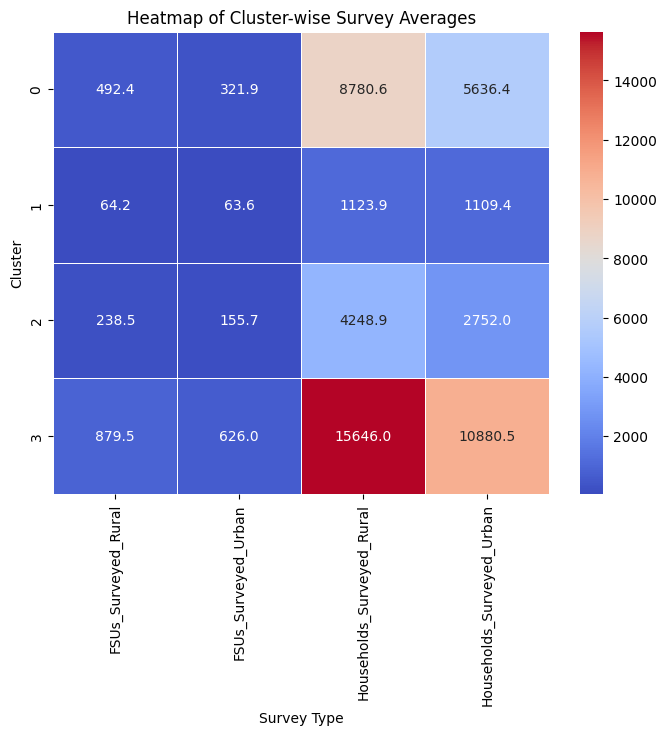

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(cluster_summary, cmap="coolwarm", annot=True, fmt=".1f", linewidths=0.5)

plt.title("Heatmap of Cluster-wise Survey Averages")
plt.xlabel("Survey Type")
plt.ylabel("Cluster")
plt.show()


## Distribution Patterns

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\3645347850.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cluster", y="Households_Surveyed_Total", palette="viridis")


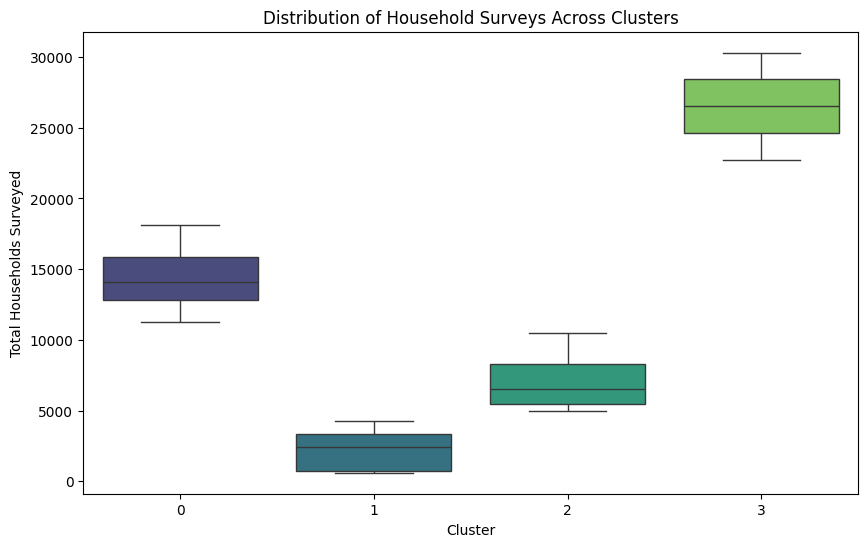

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Cluster", y="Households_Surveyed_Total", palette="viridis")

plt.xlabel("Cluster")
plt.ylabel("Total Households Surveyed")
plt.title("Distribution of Household Surveys Across Clusters")
plt.show()


## Cluster-wise Comparison of Surveyed FSUs and Households"

This radar chart visualizes the average number of surveyed FSUs and households across different clusters. The shape of each cluster highlights differences in survey intensity and data collection coverage across rural and urban regions

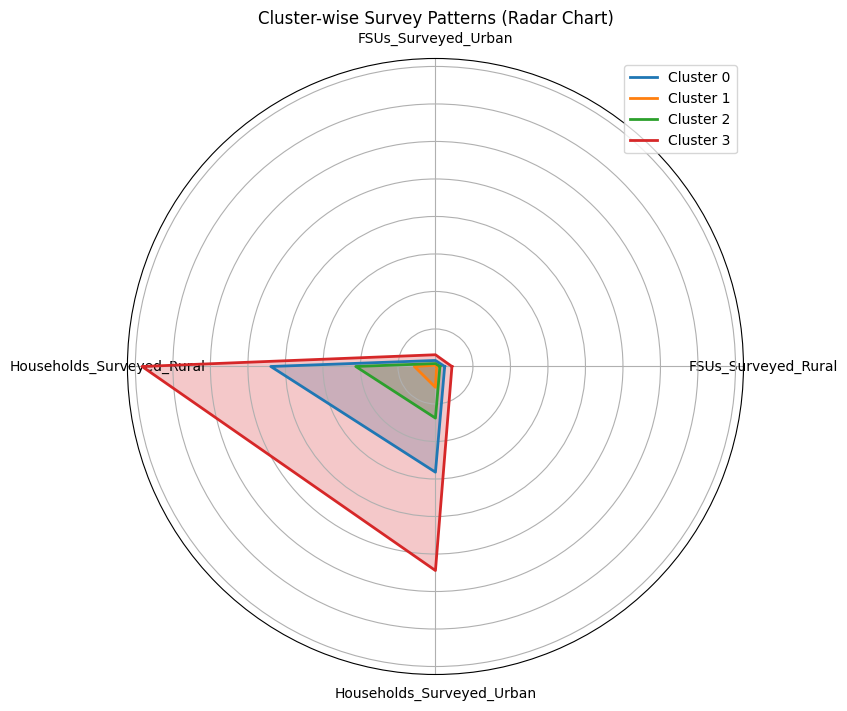

In [21]:
import numpy as np

labels = cluster_summary.columns
num_vars = len(labels)

# Set up radar chart
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cluster in cluster_summary.index:
    values = cluster_summary.loc[cluster].tolist()
    values += values[:1]  # Close the circle
    ax.plot(angles, values, label=f"Cluster {cluster}", linewidth=2)
    ax.fill(angles, values, alpha=0.25)

ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("Cluster-wise Survey Patterns (Radar Chart)")
plt.legend()
plt.show()


This radar chart visualizes survey patterns across four clusters based on FSUs and households surveyed in rural and urban areas.

##### Cluster 2 (Green): 
Highest rural household surveys, indicating strong rural coverage.

#### Cluster 0 (Blue): 
Moderate survey levels in both rural and urban areas.

##### Clusters 1 (Orange) & 3 (Red):
Lower survey activity across all metrics.

#### Key Insights:
Some clusters have high surveyed households but fewer FSUs, suggesting high population density or efficient survey methods.

Clusters with low household surveys despite high FSUs may indicate survey inefficiencies.

## Predicting Households Surveyed Using FSUs Surveyed

The goal is to find a relationship between the number of FSUs surveyed (independent variable, X) and the total number of households surveyed (dependent variable, y) using a linear model. This model is then used to predict the number of households surveyed if 10,000 FSUs were surveyed

In [22]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df["FSUs_Surveyed_Rural"] + df["FSUs_Surveyed_Urban"]
y = df["Households_Surveyed_Total"]

X = np.array(X).reshape(-1, 1)
model = LinearRegression()
model.fit(X, y)

future_FSUs = np.array([10000]).reshape(-1, 1)  # Example: 10,000 FSUs surveyed
predicted_households = model.predict(future_FSUs)

print(f"Predicted Households Surveyed for 10,000 FSUs: {int(predicted_households)}")


Predicted Households Surveyed for 10,000 FSUs: 177060


C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\2996496706.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Predicted Households Surveyed for 10,000 FSUs: {int(predicted_households)}")


Based on the existing survey data, a linear regression model was used to predict the total number of households surveyed when 10,000 FSUs are covered. The model estimates that approximately 177,060 households will be surveyed. This projection helps in planning large-scale data collection efforts by providing an expected household coverage based on the surveyed FSUs.

# Table 3.1: Average MPCE across fractile classes of MPCE, All-India

In [23]:
import pandas as pd

data = {
    "MPCE_Fraction": ["0–5%", "5–10%", "10–20%", "20–30%", "30–40%", "40–50%", "50–60%", "60–70%", "70–80%", "80–90%", "90–95%", "95–100%", "All classes"],
    "Rural_Upper_Limit": [1968, 2260, 2665, 2997, 3292, 3674, 4067, 4606, 5142, 6007, 7141, 7607, None],
    "Rural_Avg_MPCE": [1677, 2126, 2473, 2783, 3103, 3492, 3866, 4366, 4885, 5768, 6496, 6927, 4122],
    "Urban_Upper_Limit": [2834, 3313, 3795, 4373, 4994, 5595, 6344, 7178, 8096, 9102, 10661, 14521, None],
    "Urban_Avg_MPCE": [2327, 3095, 3543, 3935, 4390, 4852, 5334, 5934, 6535, 7359, 8434, 10910, 6996]
}

df_mpce = pd.DataFrame(data)
df_mpce.head(2)


,MPCE_Fraction,Rural_Upper_Limit,Rural_Avg_MPCE,Urban_Upper_Limit,Urban_Avg_MPCE
0,0–5%,1968.0,1677,2834.0,2327
1,5–10%,2260.0,2126,3313.0,3095


## Comparing Rural vs. Urban MPCE

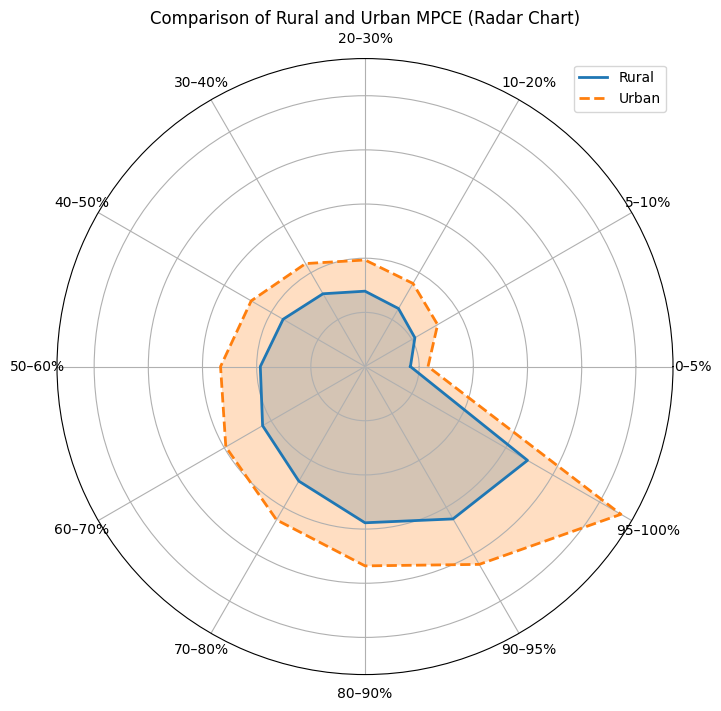

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Define labels and values
labels = df_mpce["MPCE_Fraction"][:-1]  # Exclude "All classes"
rural_values = df_mpce["Rural_Avg_MPCE"][:-1].values
urban_values = df_mpce["Urban_Avg_MPCE"][:-1].values

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # Close the radar chart

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot Rural
ax.plot(angles, np.append(rural_values, rural_values[0]), label="Rural", linewidth=2)
ax.fill(angles, np.append(rural_values, rural_values[0]), alpha=0.25)

# Plot Urban
ax.plot(angles, np.append(urban_values, urban_values[0]), label="Urban", linewidth=2, linestyle="dashed")
ax.fill(angles, np.append(urban_values, urban_values[0]), alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticklabels([])

plt.title("Comparison of Rural and Urban MPCE (Radar Chart)")
plt.legend()
plt.show()


# Rural vs. Urban MPCE Across Fractile Classes

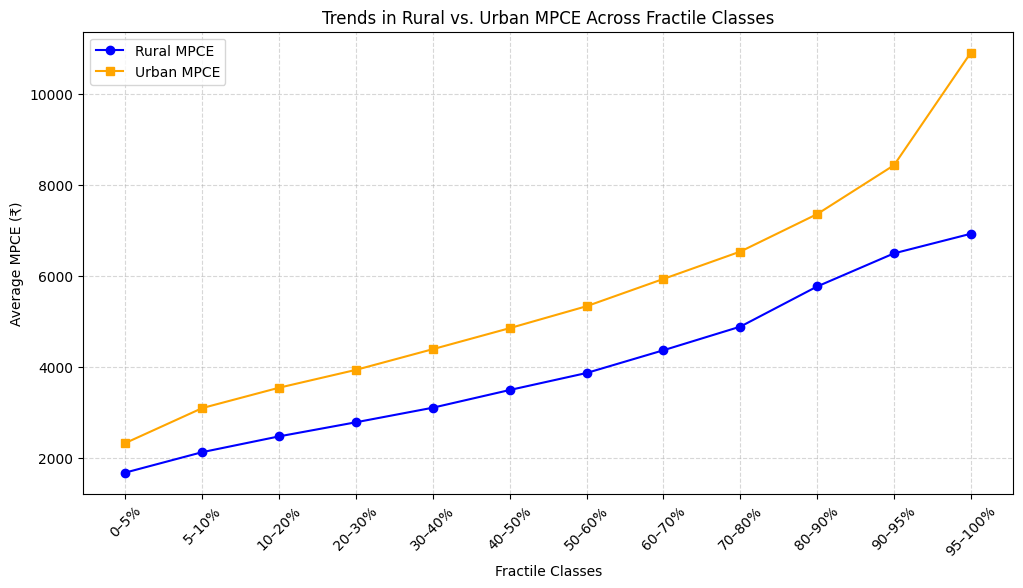

In [25]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_mpce) - 1)  # Exclude "All classes"

ax1.plot(x, df_mpce["Rural_Avg_MPCE"][:-1], marker='o', linestyle='-', color='blue', label="Rural MPCE")
ax1.plot(x, df_mpce["Urban_Avg_MPCE"][:-1], marker='s', linestyle='-', color='orange', label="Urban MPCE")

ax1.set_xticks(x)
ax1.set_xticklabels(df_mpce["MPCE_Fraction"][:-1], rotation=45)
ax1.set_ylabel("Average MPCE (₹)")
ax1.set_xlabel("Fractile Classes")
ax1.set_title("Trends in Rural vs. Urban MPCE Across Fractile Classes")
ax1.legend()

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


# Distribution of MPCE values for rural and urban areas

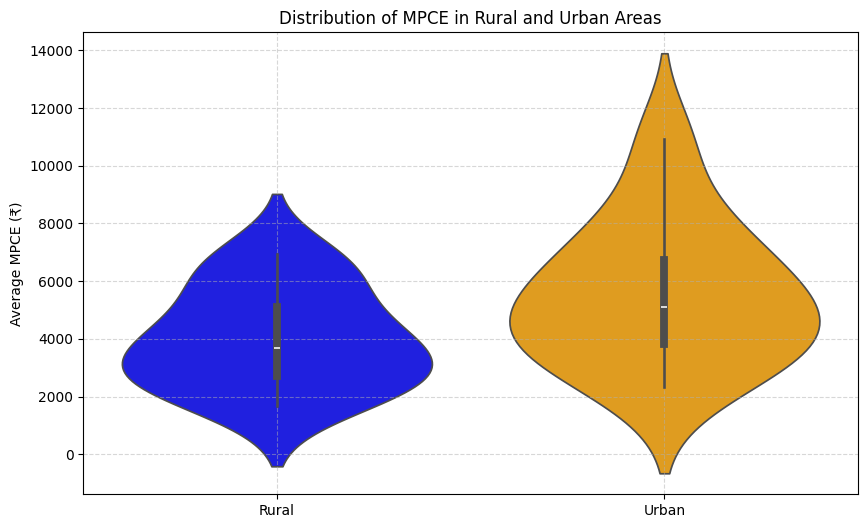

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_mpce[:-1][["Rural_Avg_MPCE", "Urban_Avg_MPCE"]], palette=["blue", "orange"])

plt.xticks(ticks=[0, 1], labels=["Rural", "Urban"])
plt.ylabel("Average MPCE (₹)")
plt.title("Distribution of MPCE in Rural and Urban Areas")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Share of MPCE Across Fractile Classes

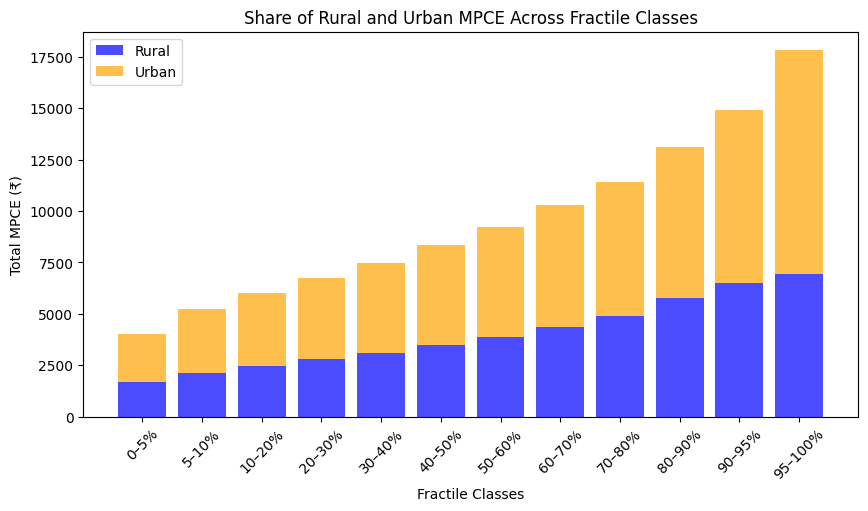

In [27]:
plt.figure(figsize=(10, 5))
plt.bar(df_mpce["MPCE_Fraction"][:-1], df_mpce["Rural_Avg_MPCE"][:-1], label="Rural", color="blue", alpha=0.7)
plt.bar(df_mpce["MPCE_Fraction"][:-1], df_mpce["Urban_Avg_MPCE"][:-1], label="Urban", color="orange", alpha=0.7, bottom=df_mpce["Rural_Avg_MPCE"][:-1])

plt.xticks(rotation=45)
plt.ylabel("Total MPCE (₹)")
plt.xlabel("Fractile Classes")
plt.title("Share of Rural and Urban MPCE Across Fractile Classes")
plt.legend()
plt.show()


## Table 3.2: Average MPCE across fractile classes of MPCE in 2022-23 and 2023-24, All-India

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Creating the DataFrame
data = {
    "Fractile_Classes": ["0-5%", "5-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50-60%", "60-70%", "70-80%", "80-90%", "90-95%", "95-100%"],
    "Rural_2022_23": [1373, 1782, 2112, 2454, 2768, 3126, 3455, 3887, 4458, 5196, 6368, 10501],
    "Urban_2022_23": [2201, 2607, 3157, 3762, 4348, 4962, 5626, 6274, 7673, 9365, 12399, 20824],
    "Rural_2023_24": [1677, 2126, 2439, 2833, 3162, 3664, 3866, 4304, 4885, 5763, 6929, 10137],
    "Urban_2023_24": [2376, 3093, 3687, 4353, 4979, 5738, 6334, 7133, 8353, 10339, 12817, 20310]
}
df = pd.DataFrame(data)
df.head(3)

,Fractile_Classes,Rural_2022_23,Urban_2022_23,Rural_2023_24,Urban_2023_24
0,0-5%,1373,2201,1677,2376
1,5-10%,1782,2607,2126,3093
2,10-20%,2112,3157,2439,3687


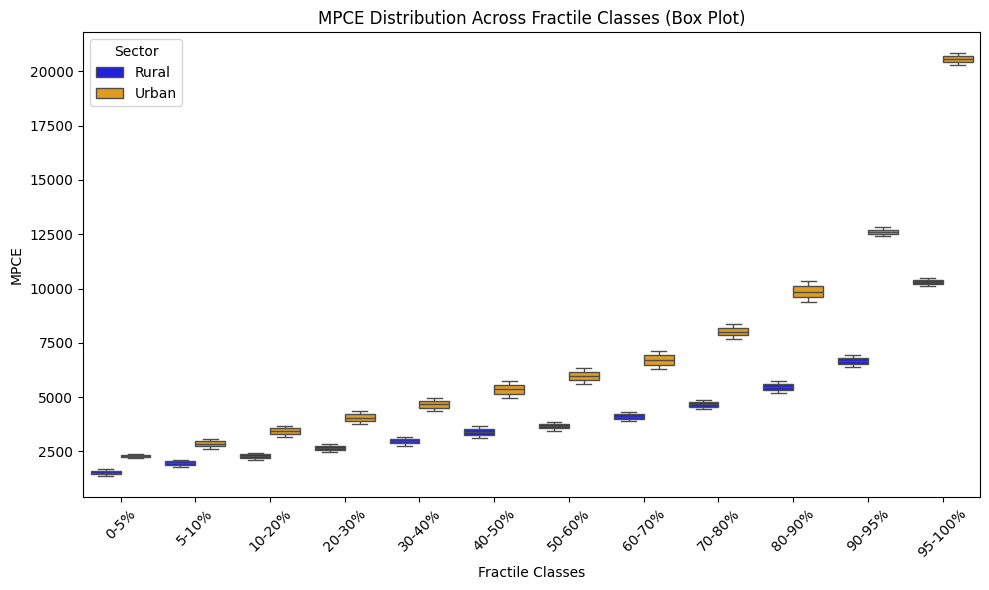

In [29]:

# Convert Fractile Classes to categorical type for proper ordering
df["Fractile_Classes"] = pd.Categorical(df["Fractile_Classes"], categories=data["Fractile_Classes"], ordered=True)

# Melt the data for Seaborn plotting
df_melted = df.melt(id_vars=["Fractile_Classes"], var_name="Category", value_name="MPCE")
df_melted["Year"] = df_melted["Category"].apply(lambda x: "2022-23" if "2022_23" in x else "2023-24")
df_melted["Sector"] = df_melted["Category"].apply(lambda x: "Rural" if "Rural" in x else "Urban")

plt.figure(figsize=(10, 6))

# Box plot
sns.boxplot(x="Fractile_Classes", y="MPCE", hue="Sector", data=df_melted, palette={"Rural": "blue", "Urban": "orange"})
plt.title("MPCE Distribution Across Fractile Classes (Box Plot)")
plt.xlabel("Fractile Classes")
plt.ylabel("MPCE")
plt.xticks(rotation=45)
plt.legend(title="Sector")

# Show plot
plt.tight_layout()
plt.show()


# 1. Lorenz Curve & Gini Coefficient Calculation

In [30]:
def gini_coefficient(values):
    values = np.sort(values)
    n = len(values)
    cumulative = np.cumsum(values)
    gini = (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n
    return gini

rural_gini = gini_coefficient(df['Rural_2023_24'])
urban_gini = gini_coefficient(df['Urban_2023_24'])
print(f"Rural Gini: {rural_gini:.3f}, Urban Gini: {urban_gini:.3f}")


Rural Gini: 0.279, Urban Gini: 0.334


# 2. CDF Plot

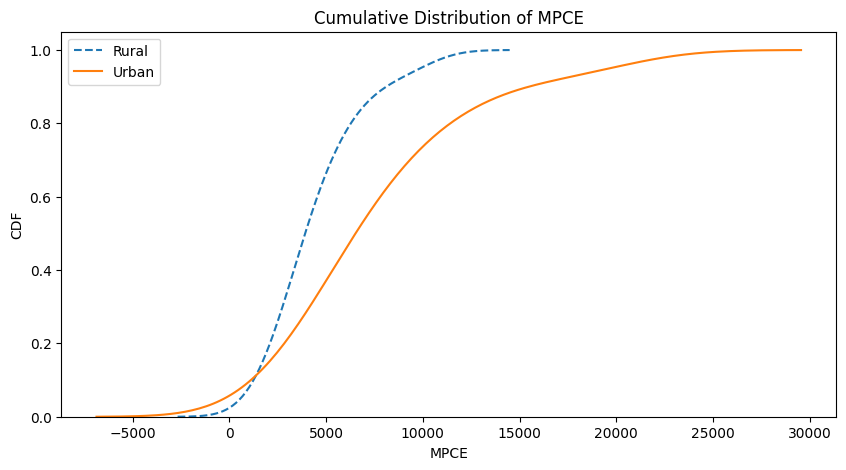

In [31]:

plt.figure(figsize=(10, 5))
sns.kdeplot(df['Rural_2023_24'], cumulative=True, label='Rural', linestyle='dashed')
sns.kdeplot(df['Urban_2023_24'], cumulative=True, label='Urban')
plt.title("Cumulative Distribution of MPCE")
plt.xlabel("MPCE")
plt.ylabel("CDF")
plt.legend()
plt.show()

# 3. Growth Rate Analysis

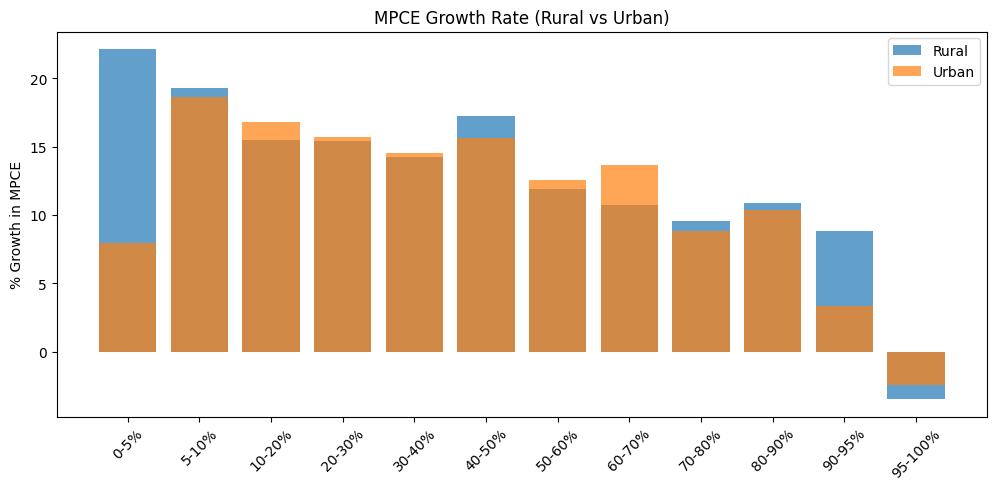

In [32]:

rural_growth = ((df['Rural_2023_24'] - df['Rural_2022_23']) / df['Rural_2022_23']) * 100
urban_growth = ((df['Urban_2023_24'] - df['Urban_2022_23']) / df['Urban_2022_23']) * 100

df['Rural_Growth'] = rural_growth
df['Urban_Growth'] = urban_growth

plt.figure(figsize=(12, 5))
plt.bar(df['Fractile_Classes'], rural_growth, label='Rural', alpha=0.7)
plt.bar(df['Fractile_Classes'], urban_growth, label='Urban', alpha=0.7)
plt.xticks(rotation=45)
plt.ylabel("% Growth in MPCE")
plt.title("MPCE Growth Rate (Rural vs Urban)")
plt.legend()
plt.show()

# 4. High-Growth vs. Low-Growth Fractile Classes

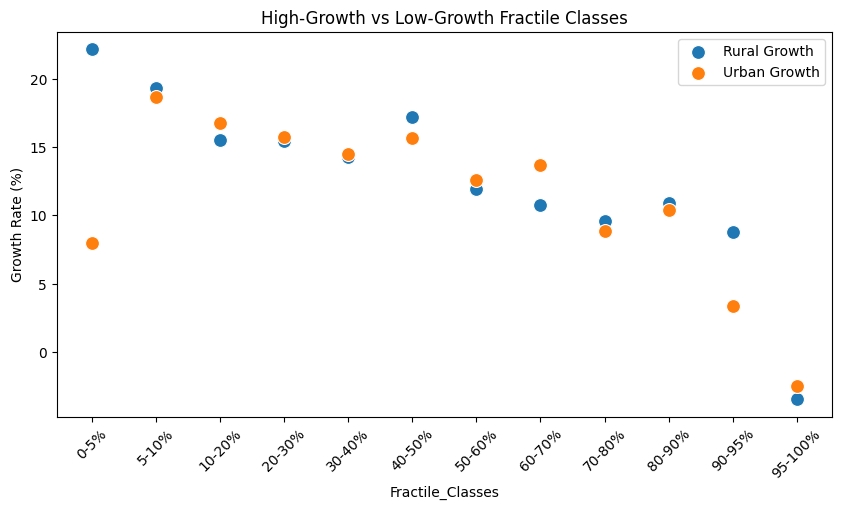

In [33]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['Fractile_Classes'], y=rural_growth, label='Rural Growth', s=100)
sns.scatterplot(x=df['Fractile_Classes'], y=urban_growth, label='Urban Growth', s=100)
plt.xticks(rotation=45)
plt.ylabel("Growth Rate (%)")
plt.title("High-Growth vs Low-Growth Fractile Classes")
plt.legend()
plt.show()


# 5. Urban-Rural MPCE Ratio Analysis

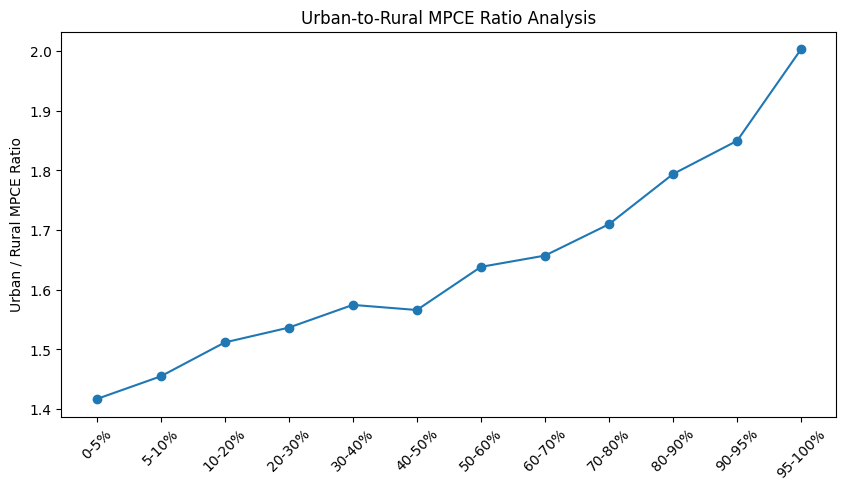

In [34]:

urban_rural_ratio = df['Urban_2023_24'] / df['Rural_2023_24']
plt.figure(figsize=(10, 5))
plt.plot(df['Fractile_Classes'], urban_rural_ratio, marker='o')
plt.xticks(rotation=45)
plt.ylabel("Urban / Rural MPCE Ratio")
plt.title("Urban-to-Rural MPCE Ratio Analysis")
plt.show()

# 6. Identifying the Tipping Point of Affordability

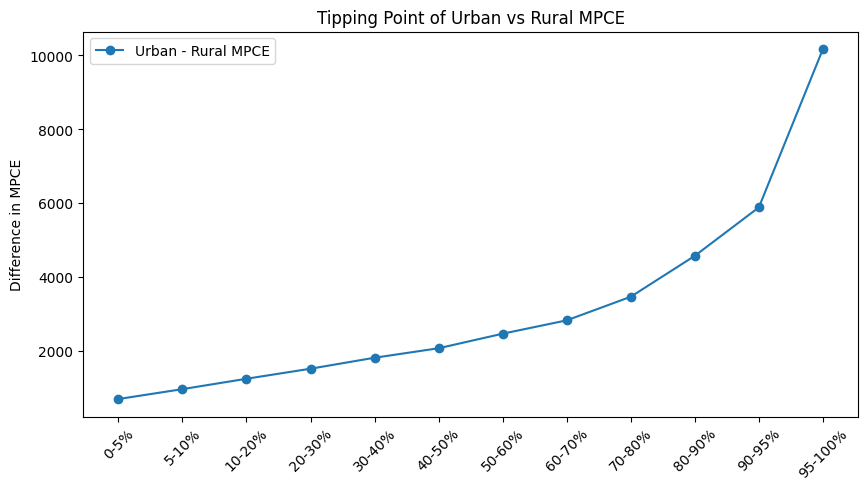

In [35]:

plt.figure(figsize=(10, 5))
diff = df['Urban_2023_24'] - df['Rural_2023_24']
plt.plot(df['Fractile_Classes'], diff, marker='o', label='Urban - Rural MPCE')
plt.xticks(rotation=45)
plt.ylabel("Difference in MPCE")
plt.title("Tipping Point of Urban vs Rural MPCE")
plt.legend()
plt.show()

# 7. Predictive Modeling

In [36]:

X = np.arange(len(df) - 1).reshape(-1, 1)
y_rural = df['Rural_2023_24'][:-1]
y_urban = df['Urban_2023_24'][:-1]
model_rural = LinearRegression().fit(X, y_rural)
model_urban = LinearRegression().fit(X, y_urban)
future_x = np.array([[len(df)]])
future_rural = model_rural.predict(future_x)
future_urban = model_urban.predict(future_x)
print(f"Predicted MPCE for 2024-25: Rural: {future_rural[0]:.2f}, Urban: {future_urban[0]:.2f}")


Predicted MPCE for 2024-25: Rural: 7082.04, Urban: 12788.49


# Table 3.2: Average MPCE and urban-rural differences in MPCE in 2022-23 and 2023-24,major States

In [37]:
import pandas as pd

data = {
    "State": [
        "Andhra Pradesh", "Assam", "Bihar", "Chhattisgarh", "Gujarat", "Haryana",
        "Jharkhand", "Karnataka", "Kerala", "Madhya Pradesh", "Maharashtra",
        "Odisha", "Punjab", "Rajasthan", "Tamil Nadu", "Telangana", "Uttar Pradesh",
        "West Bengal", "All-India"
    ],
    "Rural_2022_23": [4870, 3432, 3184, 2466, 3987, 4859, 2693, 4397, 3167, 3113, 4010, 2950, 5155, 2853, 3895, 3905, 3296, 3705, 3773],
    "Urban_2022_23": [6782, 6136, 4860, 4483, 6941, 7911, 4797, 7666, 9857, 4987, 6657, 5107, 5641, 5263, 6010, 6635, 5049, 6145, 6459],
    "Urban_Rural_Diff_2022_23": [39, 79, 53, 82, 74, 63, 78, 74, 211, 60, 66, 73, 9, 84, 54, 70, 58, 66, 71],
    "Rural_2023_24": [5327, 3736, 3537, 2796, 4116, 5777, 3096, 4905, 3411, 3461, 4175, 3375, 5170, 3015, 4101, 4343, 3595, 3920, 4122],
    "Urban_2023_24": [7182, 6794, 5222, 4781, 7166, 9072, 5405, 8295, 11028, 5541, 7456, 5737, 5617, 5543, 6363, 7059, 5763, 6569, 6996],
    "Urban_Rural_Diff_2023_24": [35, 79, 48, 71, 74, 57, 75, 69, 223, 61, 79, 70, 27, 84, 55, 63, 60, 68, 70]
}

df = pd.DataFrame(data)
df.head(4)



,State,Rural_2022_23,Urban_2022_23,Urban_Rural_Diff_2022_23,Rural_2023_24,Urban_2023_24,Urban_Rural_Diff_2023_24
0,Andhra Pradesh,4870,6782,39,5327,7182,35
1,Assam,3432,6136,79,3736,6794,79
2,Bihar,3184,4860,53,3537,5222,48
3,Chhattisgarh,2466,4483,82,2796,4781,71


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
states = ["Andhra Pradesh", "Assam", "Bihar", "Chhattisgarh", "Gujarat", "Haryana", "Jharkhand", "Karnataka", "Kerala", "Madhya Pradesh", "Maharashtra", "Odisha", "Punjab", "Rajasthan", "Tamil Nadu", "Telangana", "Uttar Pradesh", "West Bengal", "All-India"]

data = {
    "State": states,
    "Rural_2022_23": [4870, 3432, 3184, 2466, 3987, 4859, 2695, 4397, 3413, 3117, 4010, 2950, 5615, 3483, 4985, 3921, 3196, 3813, 3773],
    "Urban_2022_23": [6782, 6136, 4169, 4188, 6937, 7911, 4797, 7666, 9038, 4987, 6657, 5150, 6441, 5063, 7054, 6676, 5049, 6218, 6459],
    "Rural_2023_24": [5327, 3766, 3426, 2796, 4116, 5277, 2905, 4905, 3611, 3411, 4175, 3377, 5170, 4010, 5010, 4301, 3485, 4326, 4122],
    "Urban_2023_24": [7182, 6794, 4792, 4781, 7146, 8307, 5096, 8096, 9302, 5484, 7136, 5375, 6517, 5100, 7410, 7005, 5570, 6965, 6996]
}
df = pd.DataFrame(data)

# 1. Descriptive Statistics
print(df.describe())


       Rural_2022_23  Urban_2022_23  Rural_2023_24  Urban_2023_24
count      19.000000      19.000000      19.000000      19.000000
mean     3798.210526    6177.789474    4079.789474    6581.789474
std       841.140468    1304.494733     778.857181    1278.493409
min      2466.000000    4169.000000    2796.000000    4781.000000
25%      3190.000000    5056.000000    3455.500000    5429.500000
50%      3773.000000    6441.000000    4116.000000    6965.000000
75%      4203.500000    6859.500000    4615.500000    7164.000000
max      5615.000000    9038.000000    5327.000000    9302.000000


# 2. Growth Rate Analysis

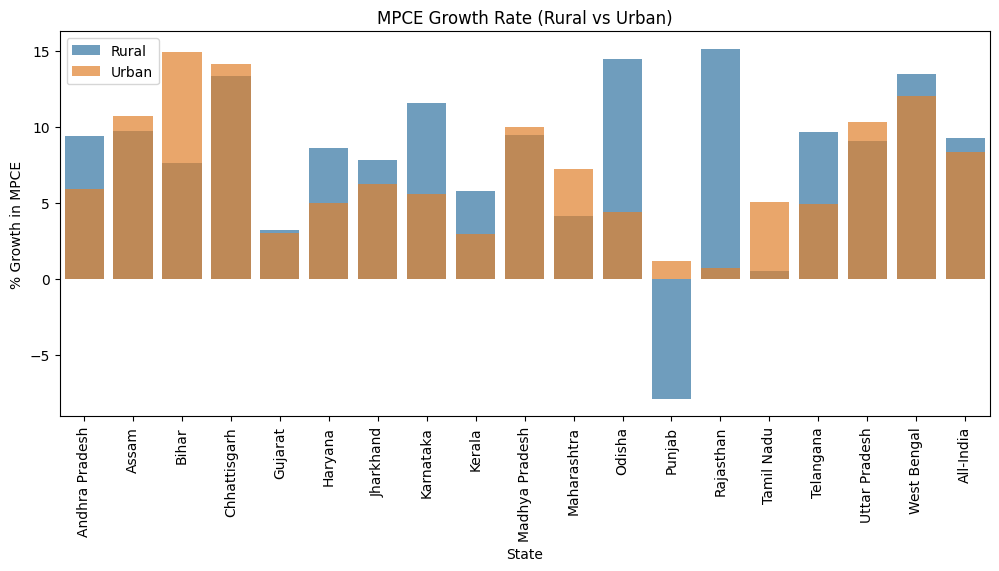

In [39]:
df['Rural_Growth'] = ((df['Rural_2023_24'] - df['Rural_2022_23']) / df['Rural_2022_23']) * 100
df['Urban_Growth'] = ((df['Urban_2023_24'] - df['Urban_2022_23']) / df['Urban_2022_23']) * 100

# Visualization of Growth Rates
plt.figure(figsize=(12, 5))
sns.barplot(x=df['State'], y=df['Rural_Growth'], label='Rural', alpha=0.7)
sns.barplot(x=df['State'], y=df['Urban_Growth'], label='Urban', alpha=0.7)
plt.xticks(rotation=90)
plt.ylabel("% Growth in MPCE")
plt.title("MPCE Growth Rate (Rural vs Urban)")
plt.legend()
plt.show()


# 3. Urban-Rural Disparity Analysis

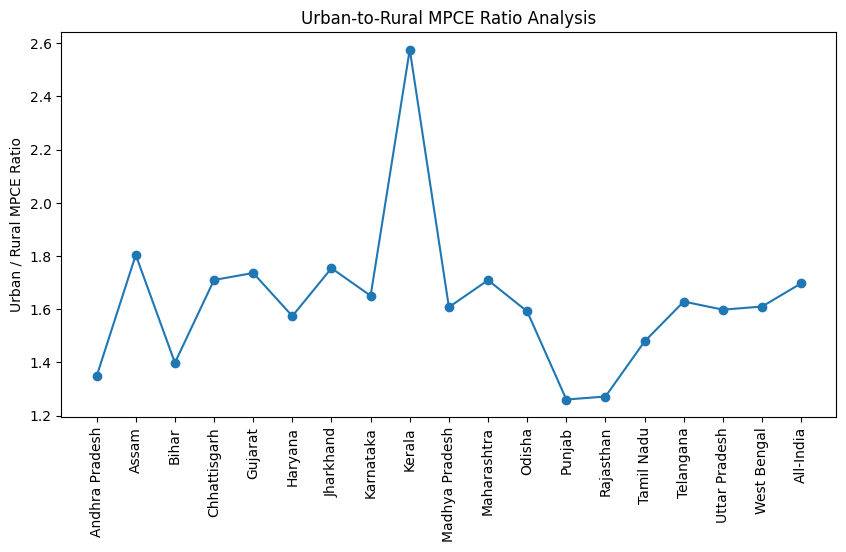

In [40]:

df['Urban-Rural Gap'] = df['Urban_2023_24'] - df['Rural_2023_24']
df['Urban-Rural Ratio'] = df['Urban_2023_24'] / df['Rural_2023_24']

plt.figure(figsize=(10, 5))
plt.plot(df['State'], df['Urban-Rural Ratio'], marker='o')
plt.xticks(rotation=90)
plt.ylabel("Urban / Rural MPCE Ratio")
plt.title("Urban-to-Rural MPCE Ratio Analysis")
plt.show()


# 4. Predictive Modeling

In [41]:

X = np.arange(len(df)).reshape(-1, 1)
model_rural = LinearRegression().fit(X, df['Rural_2023_24'])
model_urban = LinearRegression().fit(X, df['Urban_2023_24'])
future_x = np.array([[len(df)]])
future_rural = model_rural.predict(future_x)
future_urban = model_urban.predict(future_x)
print(f"Predicted MPCE for 2024-25: Rural: {future_rural[0]:.2f}, Urban: {future_urban[0]:.2f}")


Predicted MPCE for 2024-25: Rural: 4198.79, Urban: 6645.49


# 5. Clustering States Based on MPCE Patterns

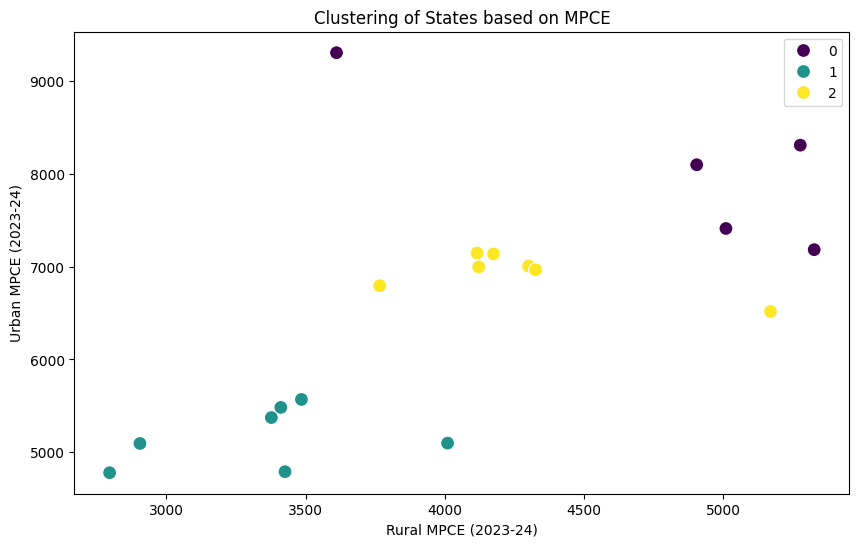

In [42]:
X_cluster = df[['Rural_2023_24', 'Urban_2023_24']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Rural_2023_24'], y=df['Urban_2023_24'], hue=df['Cluster'], palette='viridis', s=100)
plt.xlabel("Rural MPCE (2023-24)")
plt.ylabel("Urban MPCE (2023-24)")
plt.title("Clustering of States based on MPCE")
plt.legend()
plt.show()

# 6. Heatmap of MPCE across States

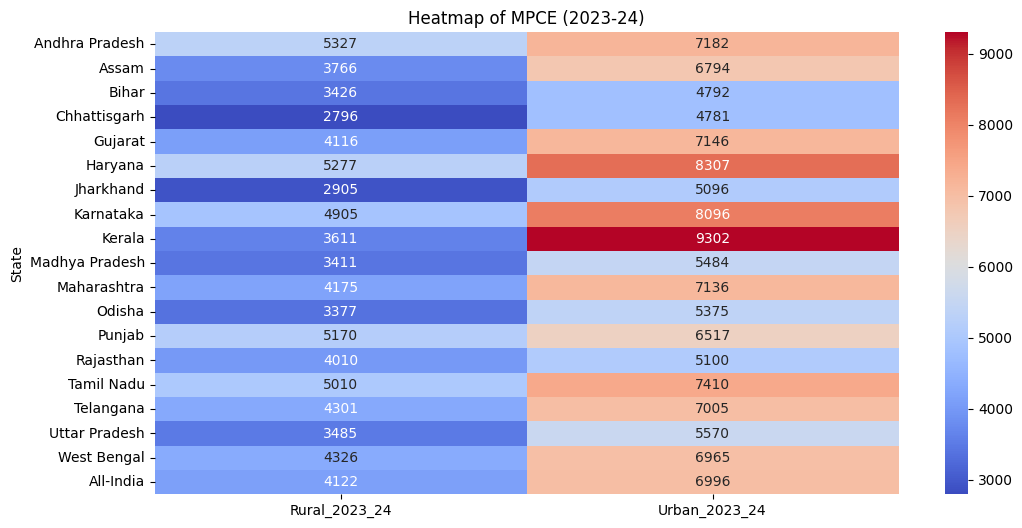

In [43]:
# 6. Heatmap of MPCE across States
plt.figure(figsize=(12, 6))
sns.heatmap(df[['Rural_2023_24', 'Urban_2023_24']].set_index(df['State']), cmap='coolwarm', annot=True, fmt=".0f")
plt.title("Heatmap of MPCE (2023-24)")
plt.show()


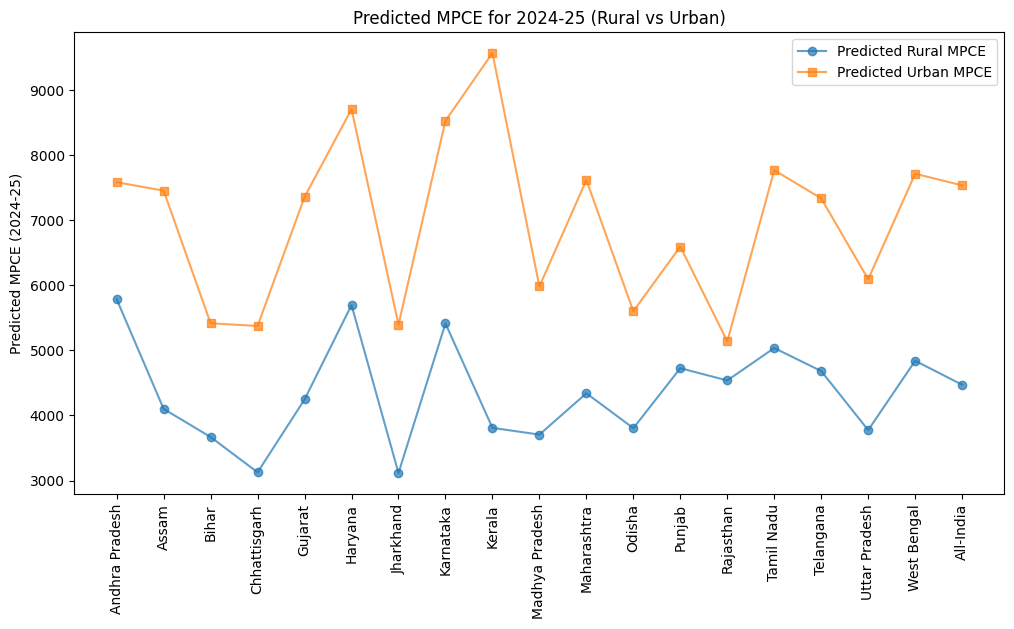

In [44]:
future_year = np.array([[2024]])
df['Predicted_Rural_2024_25'] = np.nan
df['Predicted_Urban_2024_25'] = np.nan

for i in range(len(df)):
    X = np.array([2022, 2023]).reshape(-1, 1)
    y_rural = np.array([df.loc[i, 'Rural_2022_23'], df.loc[i, 'Rural_2023_24']])
    y_urban = np.array([df.loc[i, 'Urban_2022_23'], df.loc[i, 'Urban_2023_24']])
    
    model_rural = LinearRegression().fit(X, y_rural)
    model_urban = LinearRegression().fit(X, y_urban)
    
    df.loc[i, 'Predicted_Rural_2024_25'] = model_rural.predict(future_year)[0]
    df.loc[i, 'Predicted_Urban_2024_25'] = model_urban.predict(future_year)[0]

# Visualization using Line Plot
plt.figure(figsize=(12, 6))
plt.plot(df['State'], df['Predicted_Rural_2024_25'], marker='o', linestyle='-', label='Predicted Rural MPCE', alpha=0.7)
plt.plot(df['State'], df['Predicted_Urban_2024_25'], marker='s', linestyle='-', label='Predicted Urban MPCE', alpha=0.7)
plt.xticks(rotation=90)
plt.ylabel("Predicted MPCE (2024-25)")
plt.title("Predicted MPCE for 2024-25 (Rural vs Urban)")
plt.legend()
plt.show()

# Table 3.3: Trend in MPCE since 1999-’00, All-India

In [45]:
import pandas as pd

data = {
    "Year": ["1999-00", "2004-05", "2009-10", "2011-12", "2022-23", "2023-24"],
    "Rural_Nominal": [486, 579, 1054, 1430, 3773, 4122],
    "Urban_Nominal": [855, 1105, 1984, 2630, 6459, 6996],
    "Rural_Real": [978, 1054, 1239, 1430, 2008, 2079],
    "Urban_Real": [1823, 1946, 2358, 2630, 3510, 3632]
}

df = pd.DataFrame(data)
df.head(2)


,Year,Rural_Nominal,Urban_Nominal,Rural_Real,Urban_Real
0,1999-00,486,855,978,1823
1,2004-05,579,1105,1054,1946


# 1. Growth Rate of MPCE Over the Years (Nominal & Real Price)

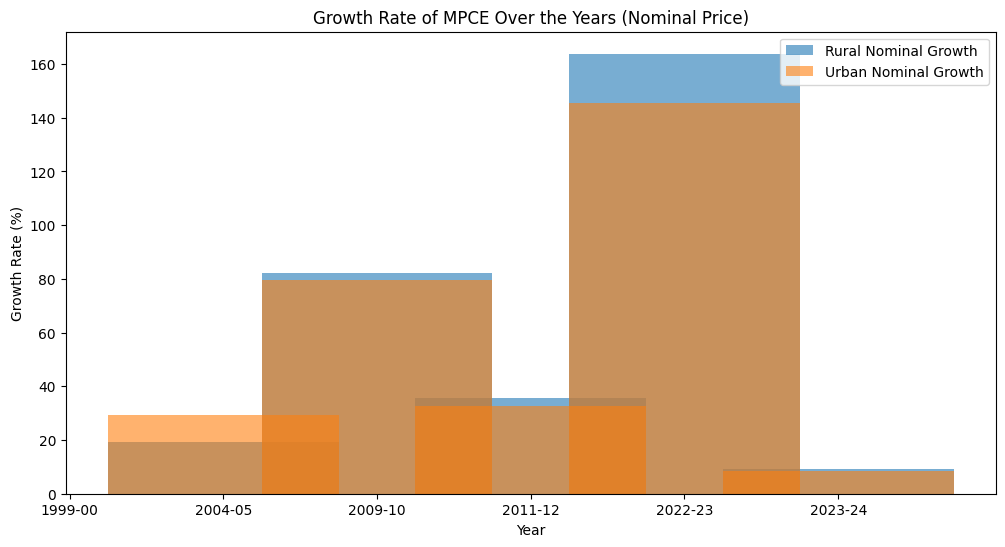

In [46]:

def growth_rate(series):
    return series.pct_change() * 100

df["Rural_Nominal_Growth"] = growth_rate(df["Rural_Nominal"])
df["Urban_Nominal_Growth"] = growth_rate(df["Urban_Nominal"])
df["Rural_Real_Growth"] = growth_rate(df["Rural_Real"])
df["Urban_Real_Growth"] = growth_rate(df["Urban_Real"])

plt.figure(figsize=(12, 6))
plt.bar(df["Year"], df["Rural_Nominal_Growth"], width=1.5, label="Rural Nominal Growth", alpha=0.6)
plt.bar(df["Year"], df["Urban_Nominal_Growth"], width=1.5, label="Urban Nominal Growth", alpha=0.6)
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.title("Growth Rate of MPCE Over the Years (Nominal Price)")
plt.legend()
plt.show()

# 2. Urban-Rural MPCE Ratio Over Time

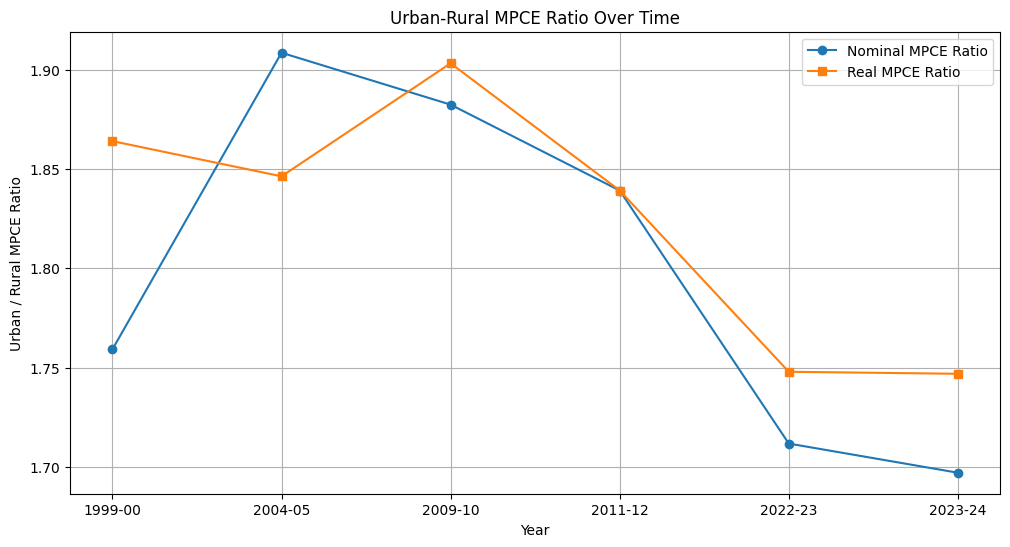

In [47]:

df["Urban_Rural_Ratio_Nominal"] = df["Urban_Nominal"] / df["Rural_Nominal"]
df["Urban_Rural_Ratio_Real"] = df["Urban_Real"] / df["Rural_Real"]

plt.figure(figsize=(12, 6))
plt.plot(df["Year"], df["Urban_Rural_Ratio_Nominal"], marker="o", label="Nominal MPCE Ratio")
plt.plot(df["Year"], df["Urban_Rural_Ratio_Real"], marker="s", label="Real MPCE Ratio")
plt.xlabel("Year")
plt.ylabel("Urban / Rural MPCE Ratio")
plt.title("Urban-Rural MPCE Ratio Over Time")
plt.legend()
plt.grid()
plt.show()

# 3. Projected Future MPCE Using Exponential Trend

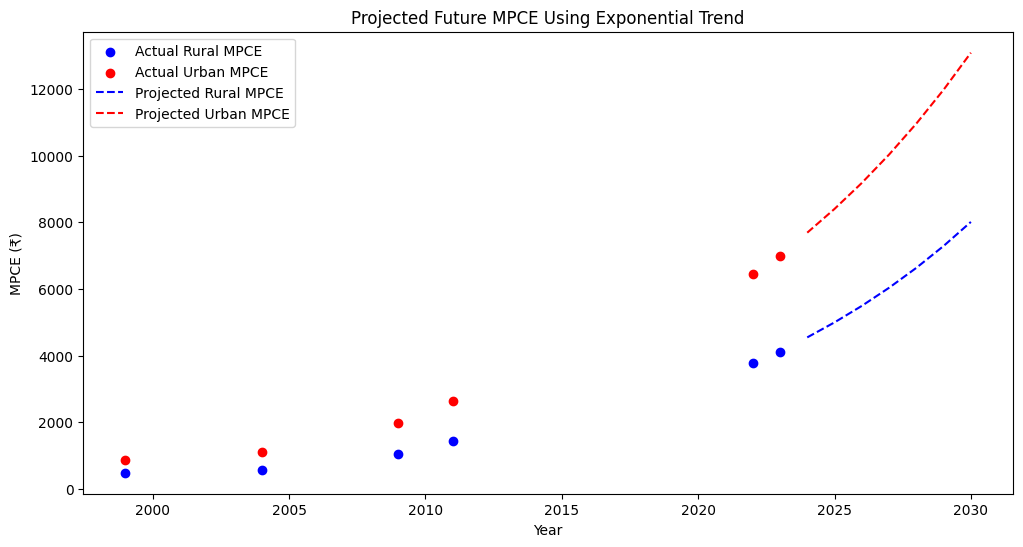

In [48]:
from scipy.optimize import curve_fit

# Creating the DataFrame
data = {
    "Year": [1999, 2004, 2009, 2011, 2022, 2023],
    "Rural_Nominal": [486, 579, 1054, 1430, 3773, 4122],
    "Urban_Nominal": [855, 1105, 1984, 2630, 6459, 6996],
    "Rural_Real": [978, 1054, 1239, 1430, 2008, 2079],
    "Urban_Real": [1823, 1946, 2358, 2630, 3510, 3632]
}
df = pd.DataFrame(data)
def exp_growth(x, a, b):
    return a * np.exp(b * (x - 1999))

years = np.array(df["Year"], dtype=float)
future_years = np.arange(2024, 2031, dtype=float)

params_rural, _ = curve_fit(exp_growth, years, df["Rural_Nominal"].astype(float), maxfev=5000)
params_urban, _ = curve_fit(exp_growth, years, df["Urban_Nominal"].astype(float), maxfev=5000)

predicted_rural = exp_growth(future_years, *params_rural)
predicted_urban = exp_growth(future_years, *params_urban)

plt.figure(figsize=(12, 6))
plt.scatter(df["Year"], df["Rural_Nominal"], label="Actual Rural MPCE", color='blue')
plt.scatter(df["Year"], df["Urban_Nominal"], label="Actual Urban MPCE", color='red')
plt.plot(future_years, predicted_rural, linestyle='dashed', color='blue', label="Projected Rural MPCE")
plt.plot(future_years, predicted_urban, linestyle='dashed', color='red', label="Projected Urban MPCE")
plt.xlabel("Year")
plt.ylabel("MPCE (₹)")
plt.title("Projected Future MPCE Using Exponential Trend")
plt.legend()
plt.show()

## Table 3.5: Absolute and percentage break-up of MPCE by item groups in 2023-24: All-India

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Creating DataFrame
mpce_data = {
    "Item Group": [
        "cereals & cereal substitutes", "pulses & their products", "sugar & salt", "milk & milk products",
        "vegetables", "fruits", "egg, fish & meat", "edible oil", "spices", "beverages, refreshments, processed food",
        "food total", "pan, tobacco & intoxicants", "fuel and light"
    ],
    "Rural_MPCE": [206, 84, 37, 348, 248, 158, 203, 114, 135, 406, 1939, 158, 252],
    "Urban_MPCE": [263, 98, 40, 503, 288, 271, 249, 127, 161, 776, 2776, 166, 391],
    "Rural_Share": [4.99, 2.04, 0.89, 8.44, 6.03, 3.85, 4.92, 2.77, 3.27, 9.84, 47.04, 3.84, 6.11],
    "Urban_Share": [3.76, 1.40, 0.57, 7.19, 4.12, 3.87, 3.56, 1.82, 2.30, 11.09, 39.68, 2.37, 5.59]
}
df_mpce = pd.DataFrame(mpce_data)

# 1. Visualization of Consumption Priorities: Rural vs. Urban

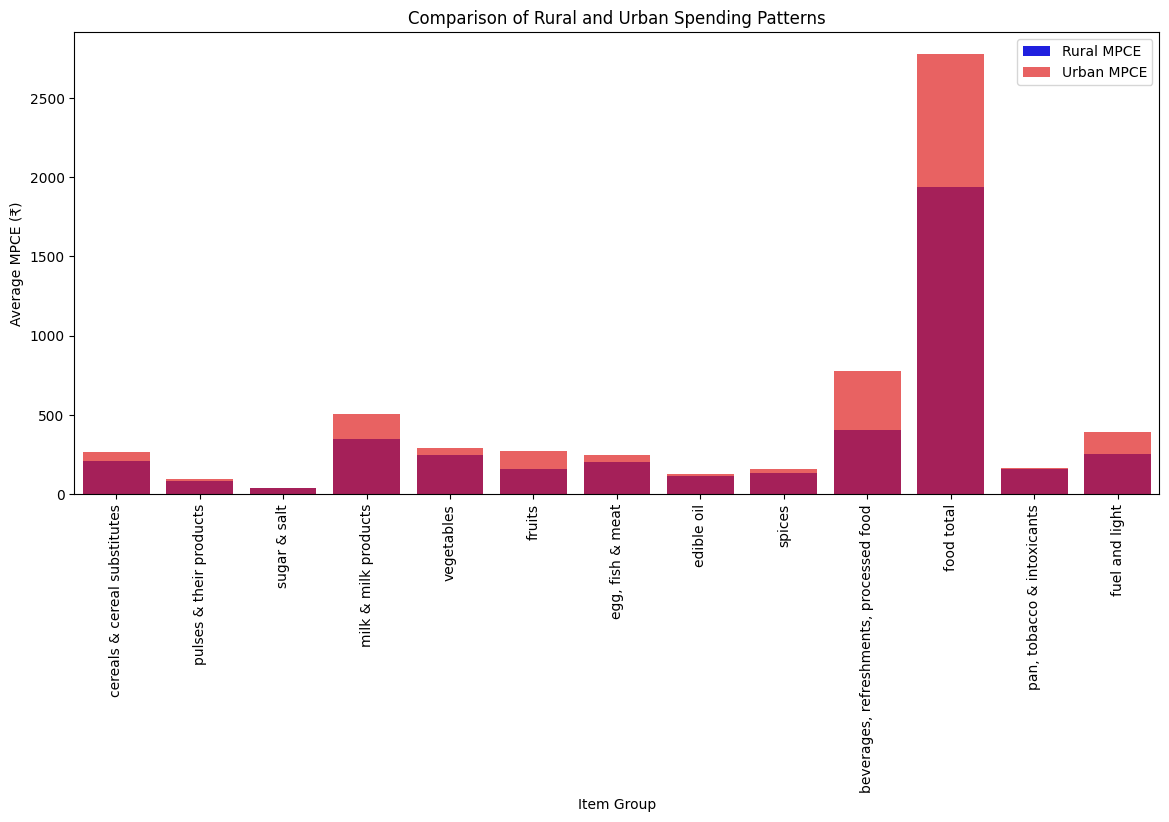

In [50]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_mpce, x="Item Group", y="Rural_MPCE", color="blue", label="Rural MPCE")
sns.barplot(data=df_mpce, x="Item Group", y="Urban_MPCE", color="red", label="Urban MPCE", alpha=0.7)
plt.xticks(rotation=90)
plt.ylabel("Average MPCE (₹)")
plt.title("Comparison of Rural and Urban Spending Patterns")
plt.legend()
plt.show()

# 2. Pie Charts for Food vs. Non-Food Spending Shares

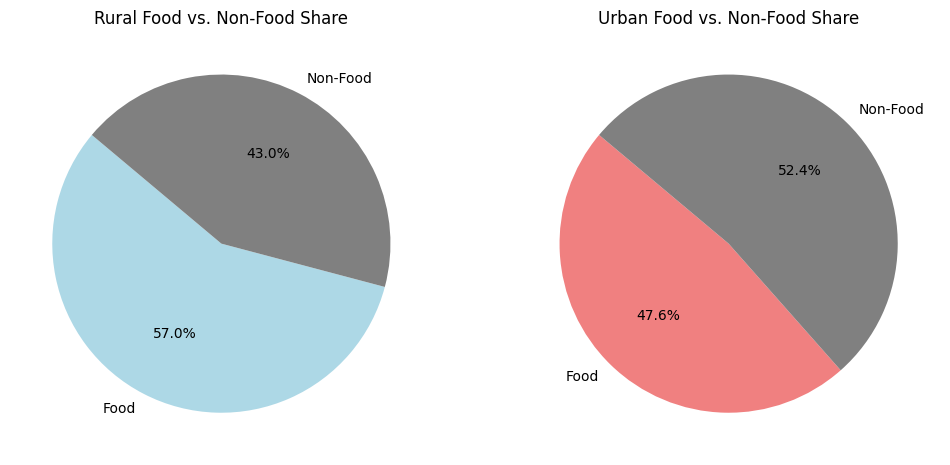

In [51]:
food_vs_nonfood_rural = [df_mpce[df_mpce["Item Group"] != "food total"]["Rural_Share"].sum(),
                          100 - df_mpce[df_mpce["Item Group"] != "food total"]["Rural_Share"].sum()]
food_vs_nonfood_urban = [df_mpce[df_mpce["Item Group"] != "food total"]["Urban_Share"].sum(),
                          100 - df_mpce[df_mpce["Item Group"] != "food total"]["Urban_Share"].sum()]
labels = ["Food", "Non-Food"]
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].pie(food_vs_nonfood_rural, labels=labels, autopct="%1.1f%%", colors=["lightblue", "gray"], startangle=140)
ax[0].set_title("Rural Food vs. Non-Food Share")
ax[1].pie(food_vs_nonfood_urban, labels=labels, autopct="%1.1f%%", colors=["lightcoral", "gray"], startangle=140)
ax[1].set_title("Urban Food vs. Non-Food Share")
plt.show()

# 3. Nutritional Security: Healthy vs. Processed Food Spending

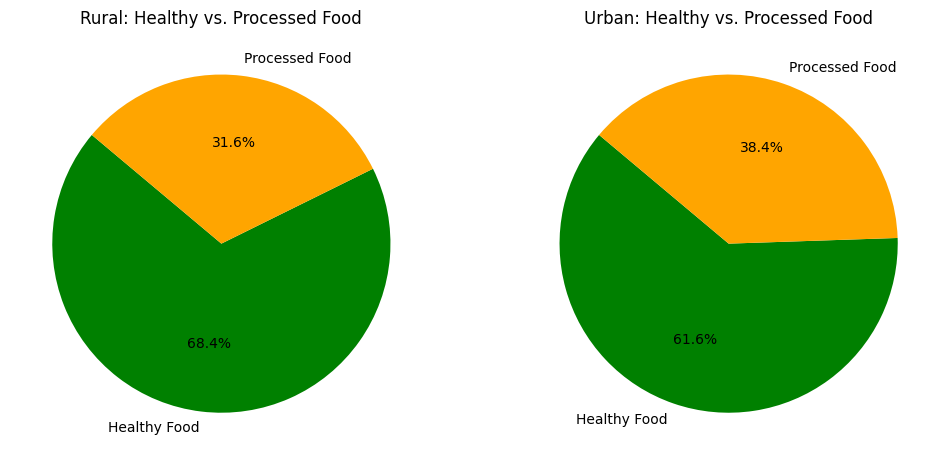

In [52]:
nutritional_items = ["milk & milk products", "vegetables", "fruits", "egg, fish & meat"]
processed_items = ["beverages, refreshments, processed food", "sugar & salt"]

df_mpce["Healthy_Food_Rural"] = df_mpce[df_mpce["Item Group"].isin(nutritional_items)]["Rural_Share"].sum()
df_mpce["Processed_Food_Rural"] = df_mpce[df_mpce["Item Group"].isin(processed_items)]["Rural_Share"].sum()
df_mpce["Healthy_Food_Urban"] = df_mpce[df_mpce["Item Group"].isin(nutritional_items)]["Urban_Share"].sum()
df_mpce["Processed_Food_Urban"] = df_mpce[df_mpce["Item Group"].isin(processed_items)]["Urban_Share"].sum()

healthy_vs_processed_rural = [df_mpce["Healthy_Food_Rural"].iloc[0], df_mpce["Processed_Food_Rural"].iloc[0]]
healthy_vs_processed_urban = [df_mpce["Healthy_Food_Urban"].iloc[0], df_mpce["Processed_Food_Urban"].iloc[0]]
labels = ["Healthy Food", "Processed Food"]
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].pie(healthy_vs_processed_rural, labels=labels, autopct="%1.1f%%", colors=["green", "orange"], startangle=140)
ax[0].set_title("Rural: Healthy vs. Processed Food")
ax[1].pie(healthy_vs_processed_urban, labels=labels, autopct="%1.1f%%", colors=["green", "orange"], startangle=140)
ax[1].set_title("Urban: Healthy vs. Processed Food")
plt.show()

In [53]:
import pandas as pd

data = {
    "Item Group": [
        "education", "medical", "conveyance", "consumer services", "misc. goods & entertainment",
        "rent", "taxes & cesses", "clothing, bedding & footwear", "durable goods", "non-food total"
    ],
    "Rural_MPCE": [133, 282, 313, 217, 256, 23, 10, 273, 267, 2183],
    "Urban_MPCE": [418, 409, 592, 407, 484, 402, 38, 396, 481, 4220],
    "Rural_Share": [3.24, 6.83, 7.59, 5.25, 6.22, 0.56, 0.21, 6.61, 6.46, 52.96],
    "Urban_Share": [5.97, 5.85, 8.47, 5.72, 6.92, 6.58, 0.53, 5.96, 6.89, 60.32]
}
df_non_food = pd.DataFrame(data)


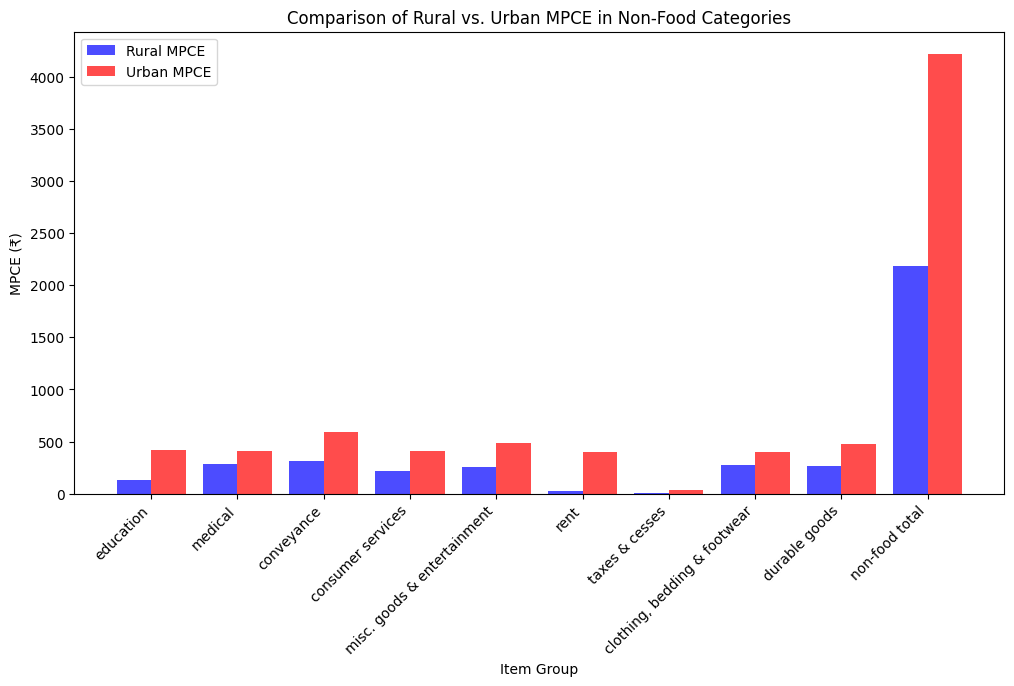

In [54]:
# 1. Comparative Bar Chart for Rural vs. Urban MPCE
plt.figure(figsize=(12, 6))
bar_width = 0.4
index = np.arange(len(df_non_food))
plt.bar(index, df_non_food["Rural_MPCE"], bar_width, label="Rural MPCE", alpha=0.7, color='blue')
plt.bar(index + bar_width, df_non_food["Urban_MPCE"], bar_width, label="Urban MPCE", alpha=0.7, color='red')
plt.xlabel("Item Group")
plt.ylabel("MPCE (₹)")
plt.title("Comparison of Rural vs. Urban MPCE in Non-Food Categories")
plt.xticks(index + bar_width / 2, df_non_food["Item Group"], rotation=45, ha='right')
plt.legend()
plt.show()

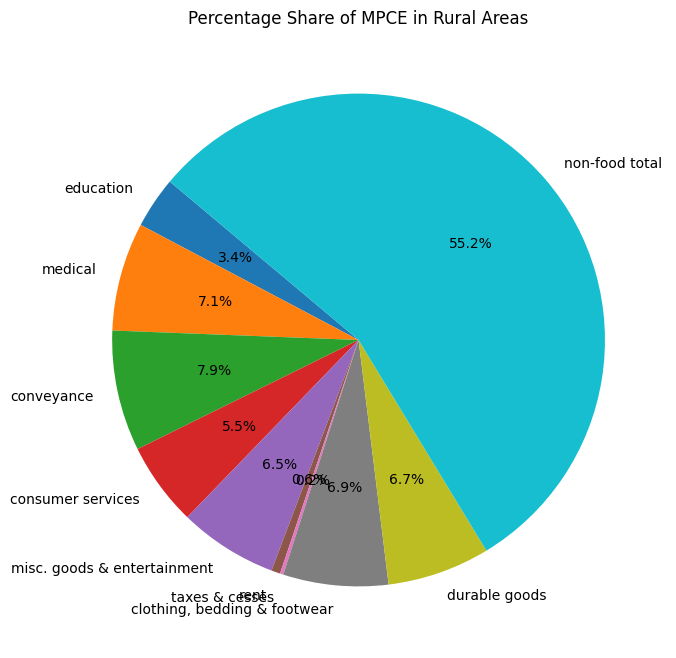

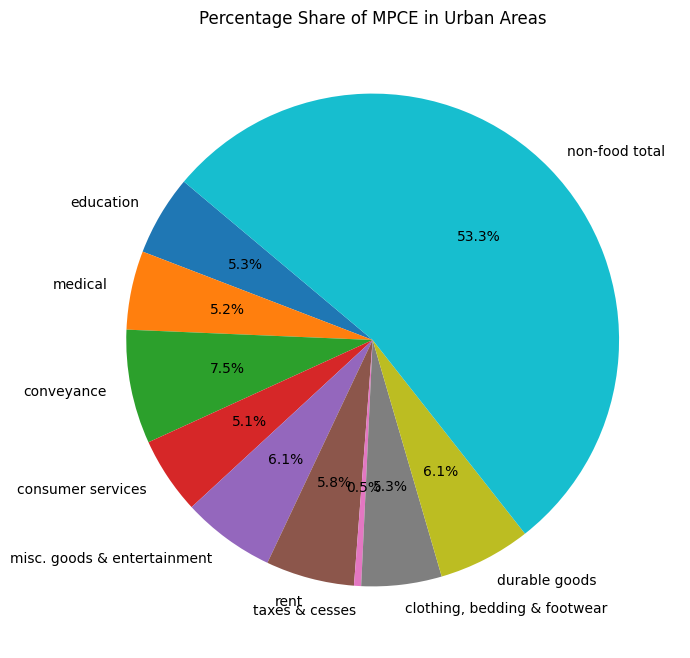

In [55]:
# 2. Pie Chart for Rural MPCE Share
plt.figure(figsize=(8, 8))
plt.pie(df_non_food["Rural_Share"], labels=df_non_food["Item Group"], autopct='%1.1f%%', startangle=140)
plt.title("Percentage Share of MPCE in Rural Areas")
plt.show()

# 3. Pie Chart for Urban MPCE Share
plt.figure(figsize=(8, 8))
plt.pie(df_non_food["Urban_Share"], labels=df_non_food["Item Group"], autopct='%1.1f%%', startangle=140)
plt.title("Percentage Share of MPCE in Urban Areas")
plt.show()

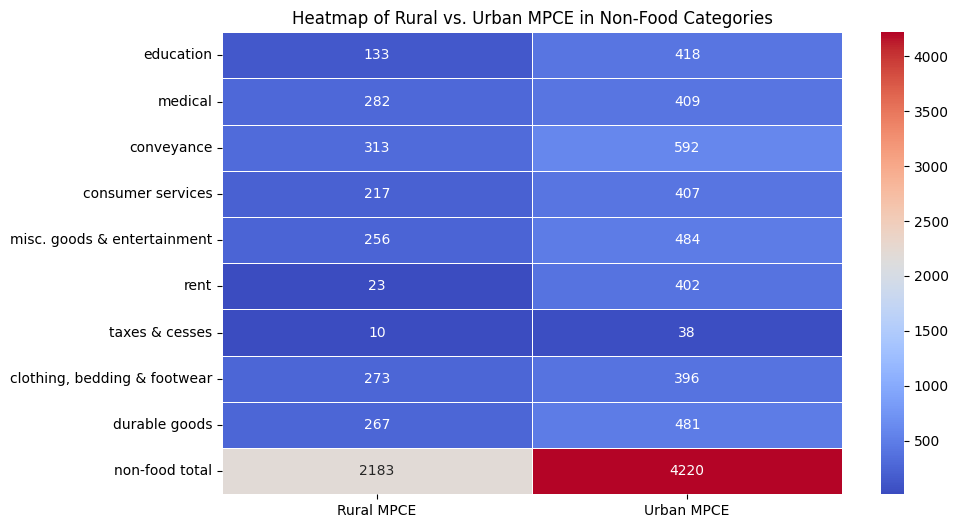

In [56]:
# 4. Heatmap for Rural vs. Urban MPCE Differences
plt.figure(figsize=(10, 6))
sns.heatmap(df_non_food[["Rural_MPCE", "Urban_MPCE"]], annot=True, fmt="d", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap of Rural vs. Urban MPCE in Non-Food Categories")
plt.xticks(ticks=[0.5, 1.5], labels=["Rural MPCE", "Urban MPCE"])
plt.yticks(ticks=np.arange(len(df_non_food)) + 0.5, labels=df_non_food["Item Group"], rotation=0)
plt.show()

# Table 3.6: Percentage share of cereals and food in total consumption expenditure in 2023-24, major states

In [57]:

data = {
    "State": [
        "Andhra Pradesh", "Assam", "Bihar", "Chhattisgarh", "Gujarat", "Haryana", 
        "Jharkhand", "Karnataka", "Kerala", "Madhya Pradesh", "Maharashtra", 
        "Odisha", "Punjab", "Rajasthan", "Tamil Nadu", "Telangana", 
        "Uttar Pradesh", "West Bengal"
    ],
    "Rural_Cereal": [4.70, 5.39, 6.59, 3.87, 4.50, 2.92, 7.90, 4.78, 3.17, 4.64, 4.76, 7.49, 2.56, 4.41, 4.35, 5.15, 4.52, 6.46],
    "Rural_Food": [45.85, 53.22, 52.53, 46.63, 49.01, 47.98, 48.77, 45.08, 40.32, 44.52, 42.74, 48.54, 42.43, 46.15, 44.27, 43.40, 47.25, 51.54],
    "Urban_Cereal": [3.97, 4.30, 5.76, 4.47, 3.79, 2.75, 5.84, 3.60, 2.86, 3.94, 3.77, 5.24, 2.88, 3.98, 3.40, 3.78, 3.68, 5.04],
    "Urban_Food": [39.43, 47.40, 48.79, 40.53, 43.37, 41.29, 40.86, 37.67, 36.55, 38.05, 36.14, 40.70, 41.30, 38.38, 38.57, 37.84, 41.37, 44.16]
}

df = pd.DataFrame(data)
df.head(5)

,State,Rural_Cereal,Rural_Food,Urban_Cereal,Urban_Food
0,Andhra Pradesh,4.70,45.85,3.97,39.43
1,Assam,5.39,53.22,4.30,47.40
2,Bihar,6.59,52.53,5.76,48.79
3,Chhattisgarh,3.87,46.63,4.47,40.53
4,Gujarat,4.50,49.01,3.79,43.37


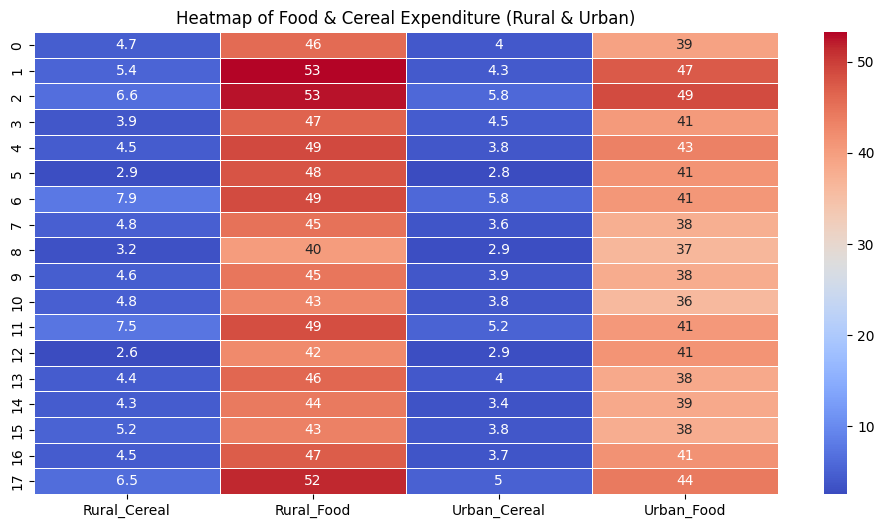

In [58]:
#Heatmap of Food & Cereal Expenditure Across States
plt.figure(figsize=(12,6))
sns.heatmap(df.iloc[:, 1:], annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap of Food & Cereal Expenditure (Rural & Urban)")
plt.show()

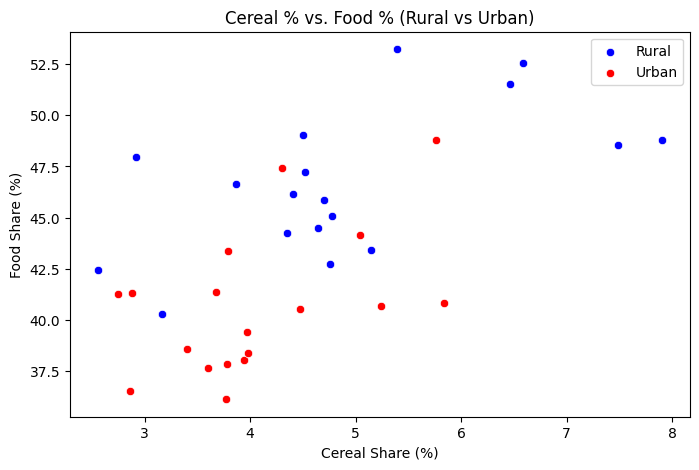

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import numpy as np
import statsmodels.api as sm
#  Correlation Analysis - Cereal % vs. Food %
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Rural_Cereal"], y=df["Rural_Food"], label="Rural", color="blue")
sns.scatterplot(x=df["Urban_Cereal"], y=df["Urban_Food"], label="Urban", color="red")
plt.xlabel("Cereal Share (%)")
plt.ylabel("Food Share (%)")
plt.title("Cereal % vs. Food % (Rural vs Urban)")
plt.legend()
plt.show()

In [60]:
# Regression Analysis
X = sm.add_constant(df["Rural_Cereal"])
model = sm.OLS(df["Rural_Food"], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Rural_Food   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     8.340
Date:                Sun, 30 Mar 2025   Prob (F-statistic):             0.0107
Time:                        10:03:50   Log-Likelihood:                -44.074
No. Observations:                  18   AIC:                             92.15
Df Residuals:                      16   BIC:                             93.93
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           39.6528      2.532     15.662   

c:\Users\ayans\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


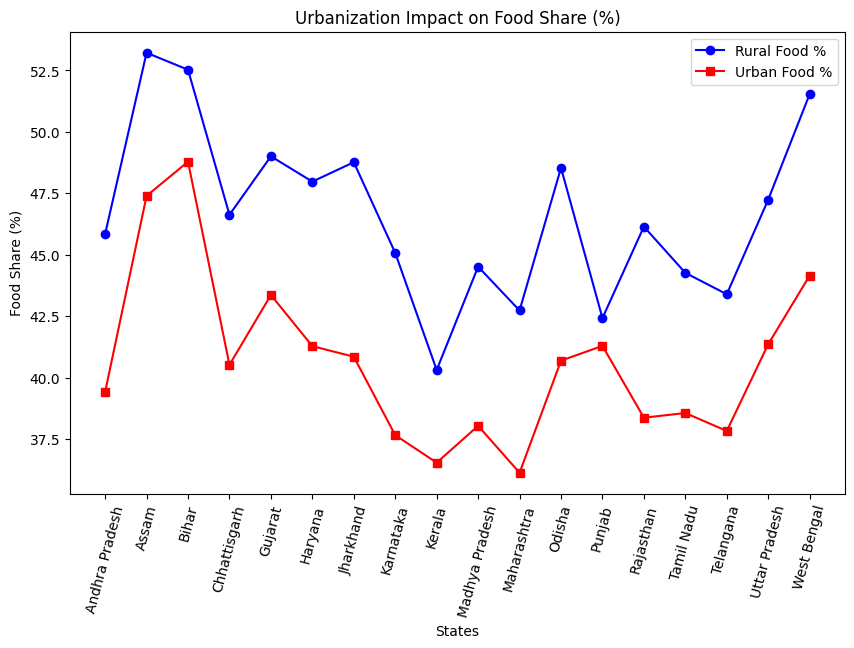

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\2123481434.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="State", y="Rural_Food", data=df_sorted, palette="viridis")


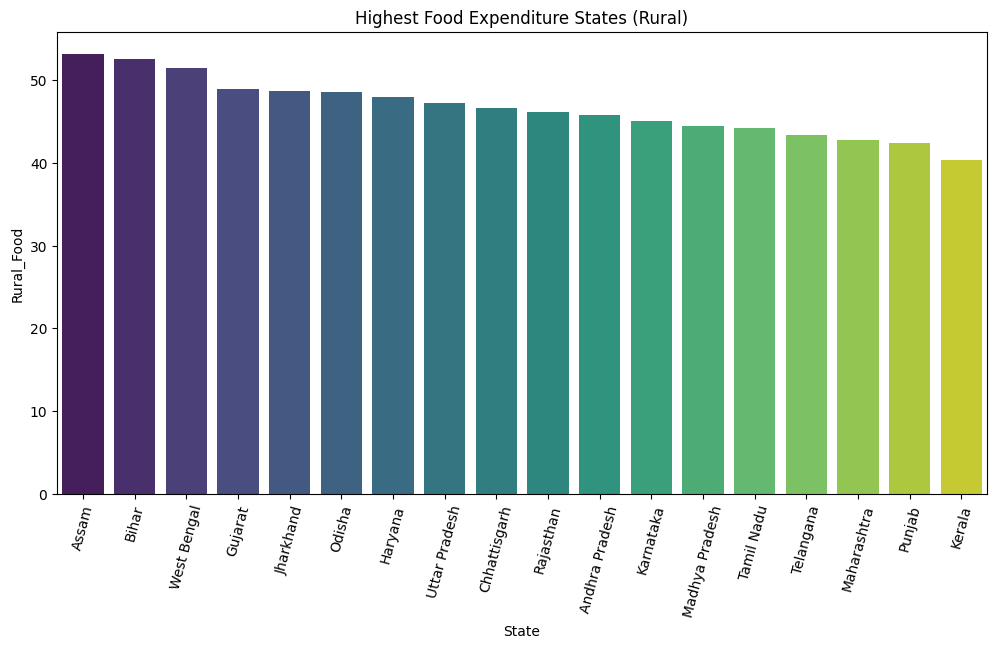

In [61]:
#  Urbanization Impact - Line Chart
plt.figure(figsize=(10,6))
plt.plot(df["State"], df["Rural_Food"], marker='o', label="Rural Food %", color="blue")
plt.plot(df["State"], df["Urban_Food"], marker='s', label="Urban Food %", color="red")
plt.xticks(rotation=75)
plt.xlabel("States")
plt.ylabel("Food Share (%)")
plt.title("Urbanization Impact on Food Share (%)")
plt.legend()
plt.show()

#  Identifying High-Food-Expenditure States
df_sorted = df.sort_values(by="Rural_Food", ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x="State", y="Rural_Food", data=df_sorted, palette="viridis")
plt.xticks(rotation=75)
plt.title("Highest Food Expenditure States (Rural)")
plt.show()

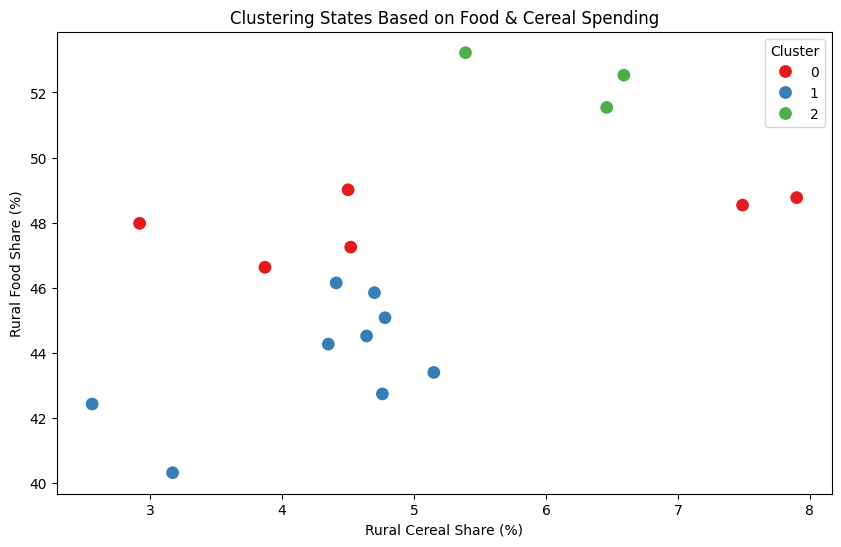

In [62]:
#  Machine Learning - Clustering States Based on Food & Cereal Spending
X_cluster = df[["Rural_Cereal", "Rural_Food", "Urban_Cereal", "Urban_Food"]]
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_cluster)

plt.figure(figsize=(10,6))
sns.scatterplot(x=df["Rural_Cereal"], y=df["Rural_Food"], hue=df["Cluster"], palette="Set1", s=100)
plt.xlabel("Rural Cereal Share (%)")
plt.ylabel("Rural Food Share (%)")
plt.title("Clustering States Based on Food & Cereal Spending")
plt.show()

# Table 3.7: Trend in per capita quantity consumption of cereals since 1999-’00

In [63]:
data = {
    "Year": ["1999-00", "2004-05", "2009-10", "2011-12", "2022-23", "2023-24"],
    "Rural": [12.72, 12.12, 11.35, 11.23, 9.61, 9.35],
    "Urban": [10.42, 9.94, 9.39, 9.32, 8.05, 8.02]
}

# Create DataFrame
df = pd.DataFrame(data)
df.columns = ["Year", "Rural", "Urban"]


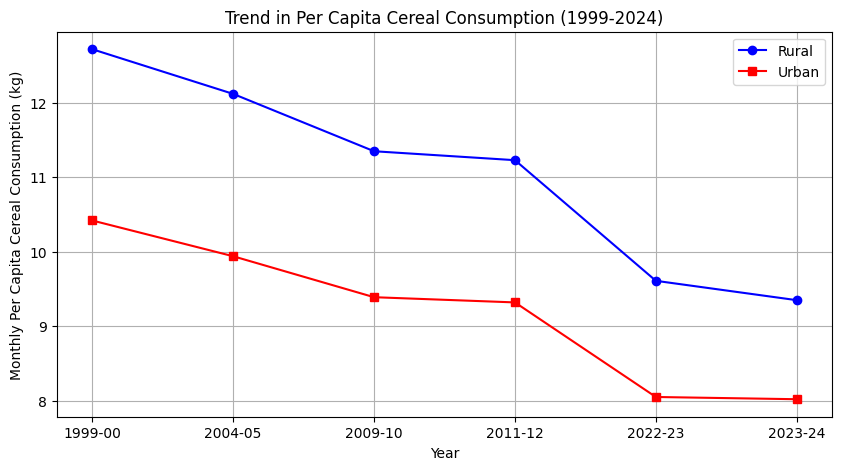

In [64]:
# Plot the trend
plt.figure(figsize=(10, 5))
plt.plot(df["Year"], df["Rural"], marker='o', label="Rural", color="blue")
plt.plot(df["Year"], df["Urban"], marker='s', label="Urban", color="red")
plt.xlabel("Year")
plt.ylabel("Monthly Per Capita Cereal Consumption (kg)")
plt.title("Trend in Per Capita Cereal Consumption (1999-2024)")
plt.legend()
plt.grid(True)
plt.show()


# Table 3.8R: Percentage share of rice, wheat and coarse grains in total consumption of cereals in 2023-24, major states - Rural

Descriptive Statistics:
       Monthly Per Capita Cereal Consumption (kg)  % Share of Rice  \
count                                   18.000000        18.000000   
mean                                     9.152222        58.488889   
std                                      1.303455        33.530054   
min                                      6.760000         3.750000   
25%                                      8.167500        29.517500   
50%                                      9.085000        66.140000   
75%                                     10.292500        90.662500   
max                                     11.500000        95.340000   

       % Share of Wheat  % Share of Coarse Grains  % Share of Other Cereals  
count         18.000000                 18.000000                 18.000000  
mean          36.933889                  4.402778                  0.175556  
std           31.455353                  6.538866                  0.193093  
min            4.630000          

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\3062996683.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="State", y="Monthly Per Capita Cereal Consumption (kg)", palette="coolwarm")


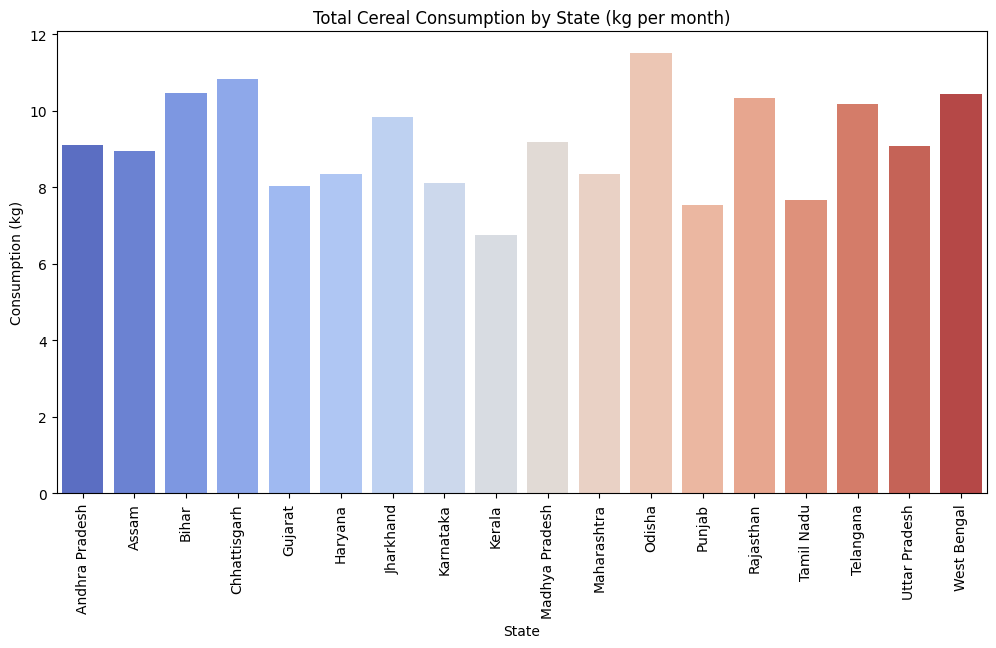

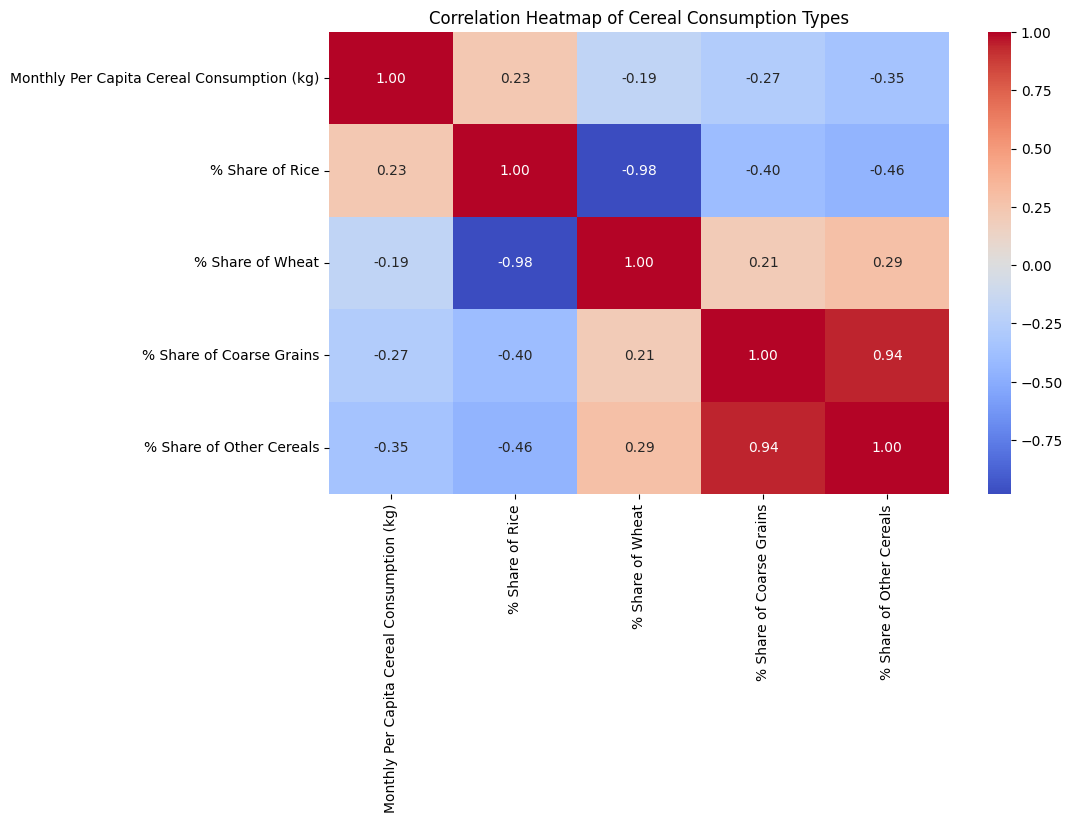


Regression Results:
                                        OLS Regression Results                                        
Dep. Variable:     Monthly Per Capita Cereal Consumption (kg)   R-squared:                       0.201
Model:                                                    OLS   Adj. R-squared:                 -0.045
Method:                                         Least Squares   F-statistic:                    0.8151
Date:                                        Sun, 30 Mar 2025   Prob (F-statistic):              0.538
Time:                                                10:03:53   Log-Likelihood:                -27.783
No. Observations:                                          18   AIC:                             65.57
Df Residuals:                                              13   BIC:                             70.02
Df Model:                                                   4                                         
Covariance Type:                                    

c:\Users\ayans\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


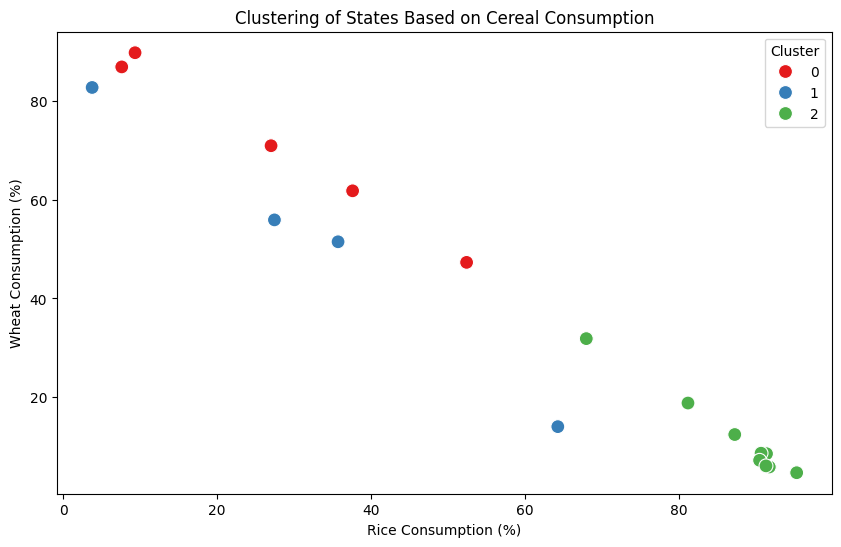

In [65]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Data Dictionary
data = {
    "State": [
        "Andhra Pradesh", "Assam", "Bihar", "Chhattisgarh", "Gujarat", "Haryana",
        "Jharkhand", "Karnataka", "Kerala", "Madhya Pradesh", "Maharashtra",
        "Odisha", "Punjab", "Rajasthan", "Tamil Nadu", "Telangana",
        "Uttar Pradesh", "West Bengal"
    ],
    "Monthly Per Capita Cereal Consumption (kg)": [
        9.10, 8.96, 10.46, 10.84, 8.03, 8.36, 9.85, 8.11, 6.76, 9.19, 8.34,
        11.50, 7.55, 10.33, 7.66, 10.18, 9.07, 10.45
    ],
    "% Share of Rice": [
        91.78, 95.34, 52.43, 91.42, 27.45, 7.60, 67.99, 64.29, 87.29, 27.01,
        35.72, 90.71, 9.33, 3.75, 90.52, 91.35, 37.61, 81.21
    ],
    "% Share of Wheat": [
        5.80, 4.63, 47.31, 8.49, 55.93, 86.97, 31.84, 13.98, 12.38, 70.98,
        51.49, 8.59, 89.85, 82.80, 7.15, 6.02, 61.83, 18.77
    ],
    "% Share of Coarse Grains": [
        2.33, 0.01, 0.25, 0.06, 16.07, 5.32, 0.15, 21.12, 0.13, 1.90, 12.42,
        0.60, 0.65, 12.93, 2.25, 2.55, 0.50, 0.01
    ],
    "% Share of Other Cereals": [
        0.10, 0.01, 0.02, 0.03, 0.54, 0.12, 0.02, 0.59, 0.21, 0.12, 0.37,
        0.10, 0.17, 0.52, 0.09, 0.07, 0.07, 0.01
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Descriptive Statistics
print("Descriptive Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Bar Chart: Total Cereal Consumption by State
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="State", y="Monthly Per Capita Cereal Consumption (kg)", palette="coolwarm")
plt.xticks(rotation=90)
plt.title("Total Cereal Consumption by State (kg per month)")
plt.xlabel("State")
plt.ylabel("Consumption (kg)")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop("State", axis=1).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Cereal Consumption Types")
plt.show()

# Regression Analysis
X = df[["% Share of Rice", "% Share of Wheat", "% Share of Coarse Grains", "% Share of Other Cereals"]]
y = df["Monthly Per Capita Cereal Consumption (kg)"]

X = sm.add_constant(X)  # Add constant for intercept
model = sm.OLS(y, X).fit()
print("\nRegression Results:")
print(model.summary())

# Clustering States Based on Consumption
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.drop("const", axis=1))

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Visualize Clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["% Share of Rice"], y=df["% Share of Wheat"], hue=df["Cluster"], palette="Set1", s=100)
plt.title("Clustering of States Based on Cereal Consumption")
plt.xlabel("Rice Consumption (%)")
plt.ylabel("Wheat Consumption (%)")
plt.show()


# Table 3.9R: Percentage share of selected food item groups in total food expenditure in 2023-24, major states - Rural

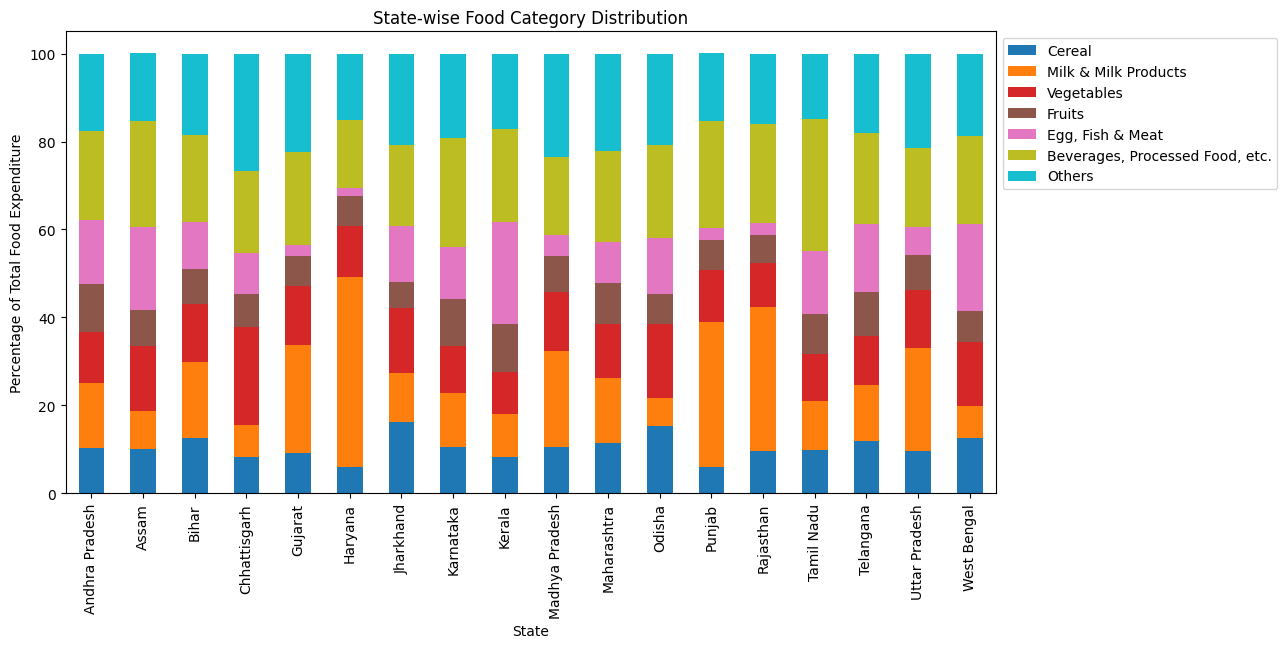

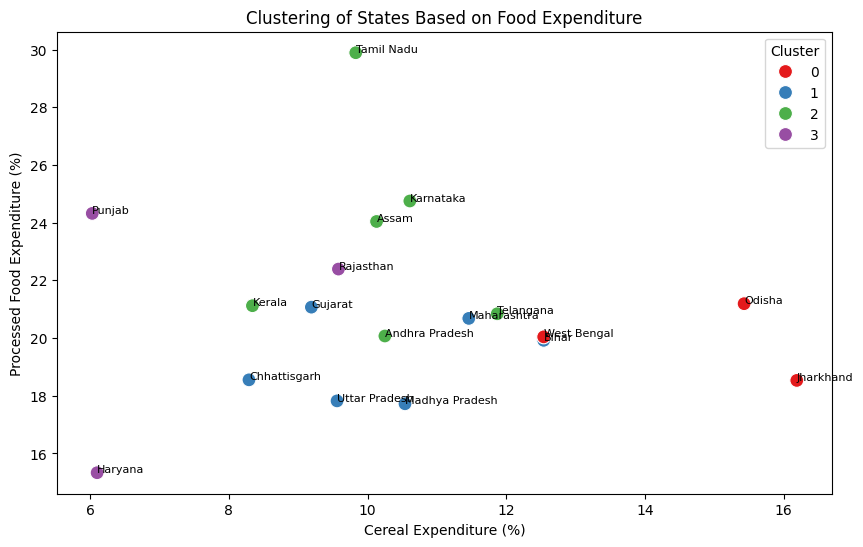

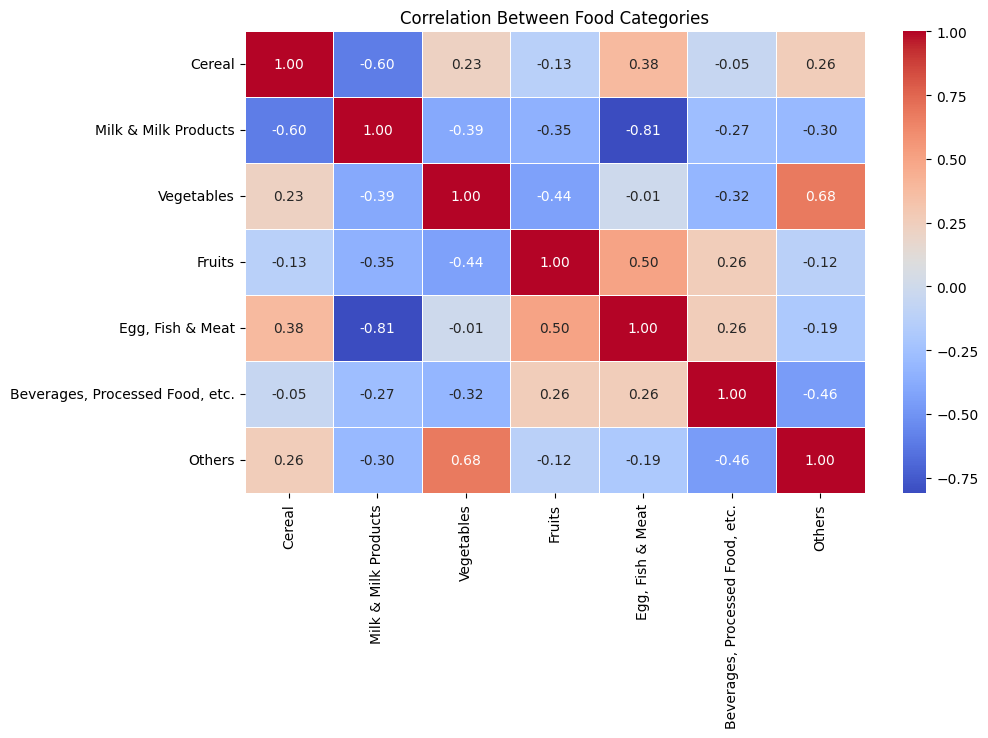

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Creating the DataFrame
data = {
    "State": [
        "Andhra Pradesh", "Assam", "Bihar", "Chhattisgarh", "Gujarat", "Haryana",
        "Jharkhand", "Karnataka", "Kerala", "Madhya Pradesh", "Maharashtra",
        "Odisha", "Punjab", "Rajasthan", "Tamil Nadu", "Telangana",
        "Uttar Pradesh", "West Bengal"
    ],
    "Cereal": [10.25, 10.13, 12.54, 8.29, 9.19, 6.10, 16.19, 10.61, 8.34, 10.54, 11.46, 15.43, 6.03, 9.58, 9.83, 11.87, 9.56, 12.54],
    "Milk & Milk Products": [14.82, 8.52, 17.29, 7.22, 24.47, 43.02, 11.18, 12.16, 9.71, 21.85, 14.69, 6.22, 33.05, 32.72, 11.28, 12.79, 23.42, 7.39],
    "Vegetables": [11.59, 14.85, 13.16, 22.36, 13.46, 11.74, 14.68, 10.84, 9.49, 13.30, 12.46, 16.98, 11.71, 10.08, 10.64, 11.14, 13.26, 14.56],
    "Fruits": [10.97, 8.15, 7.97, 7.43, 6.95, 6.76, 5.97, 10.55, 10.94, 8.25, 9.30, 6.65, 6.87, 6.48, 8.98, 10.03, 7.93, 6.96],
    "Egg, Fish & Meat": [14.64, 18.96, 10.70, 9.42, 2.43, 1.91, 12.76, 11.97, 23.33, 4.71, 9.16, 12.74, 2.68, 2.70, 14.39, 15.33, 6.44, 19.71],
    "Beverages, Processed Food, etc.": [20.07, 24.04, 19.92, 18.55, 21.07, 15.33, 18.53, 24.75, 21.12, 17.72, 20.68, 21.19, 24.32, 22.39, 29.89, 20.84, 17.82, 20.04],
    "Others": [17.66, 15.36, 18.42, 26.72, 22.43, 15.14, 20.69, 19.12, 17.07, 23.62, 22.25, 20.78, 15.35, 16.05, 14.99, 17.99, 21.57, 18.80]
}

df = pd.DataFrame(data)

### 1️⃣ Stacked Bar Chart: Food Category Distribution ###
df.set_index("State").plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab10")
plt.title("State-wise Food Category Distribution")
plt.ylabel("Percentage of Total Food Expenditure")
plt.xticks(rotation=90)
plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.show()

### 2️⃣ K-Means Clustering: Finding Similar State Groups ###
features = df.drop(columns=["State"])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_features)

# Scatter plot of two principal food categories (Cereal vs. Processed Food)
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["Cereal"], y=df["Beverages, Processed Food, etc."], hue=df["Cluster"], palette="Set1", s=100)
plt.title("Clustering of States Based on Food Expenditure")
plt.xlabel("Cereal Expenditure (%)")
plt.ylabel("Processed Food Expenditure (%)")
for i, txt in enumerate(df["State"]):
    plt.annotate(txt, (df["Cereal"][i], df["Beverages, Processed Food, etc."][i]), fontsize=8)
plt.legend(title="Cluster")
plt.show()

### 3️⃣ Heatmap: Correlation Between Food Categories ###
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=["State", "Cluster"]).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Food Categories")
plt.show()


# Table 3.9U: Percentage share of selected food item groups in total food expenditure in 2023- 24, major states - Urban

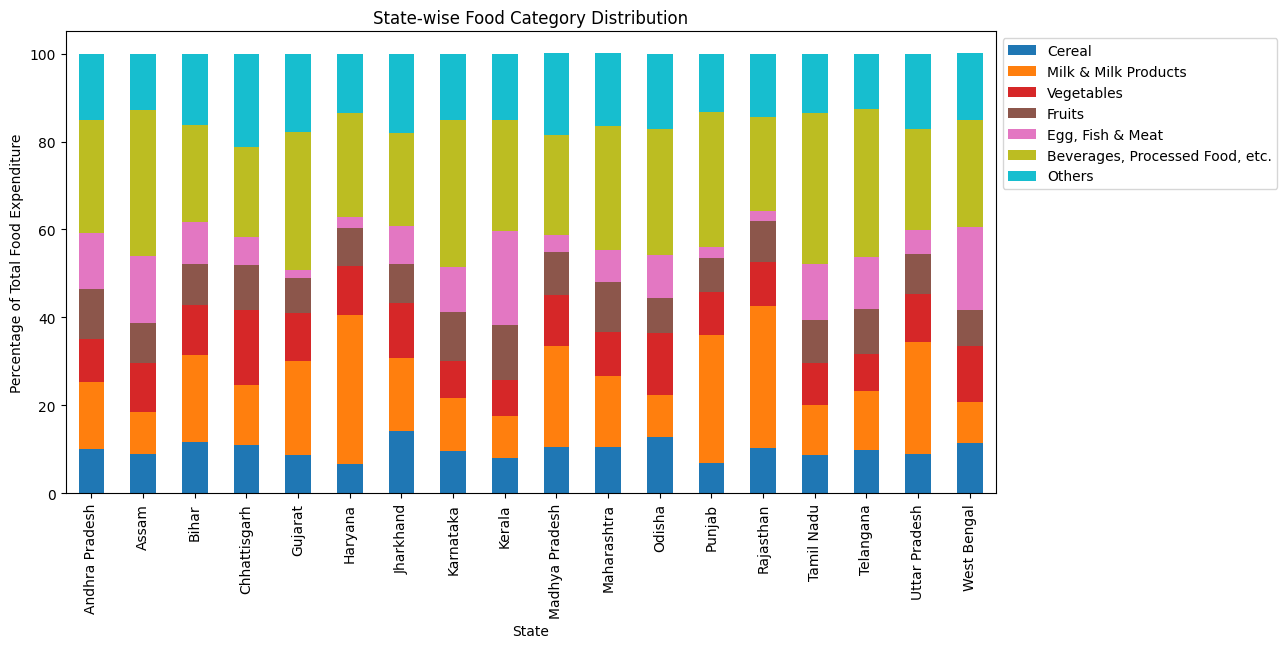

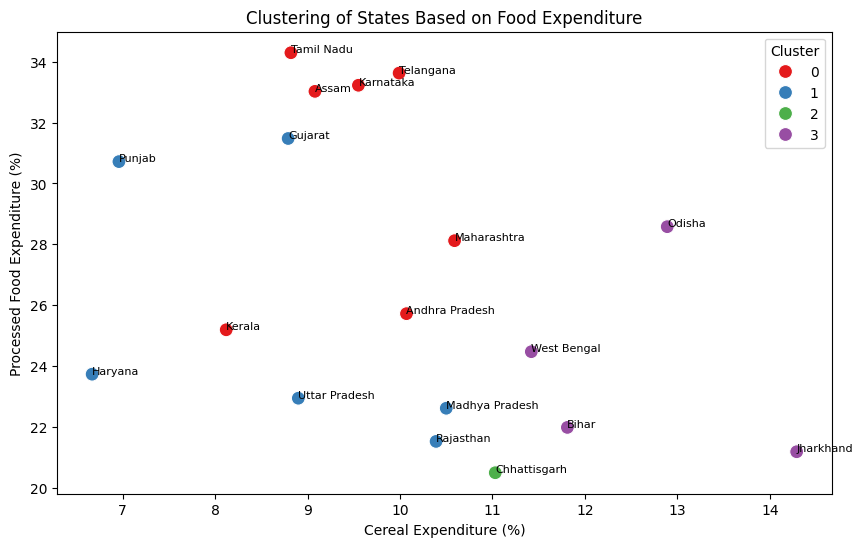

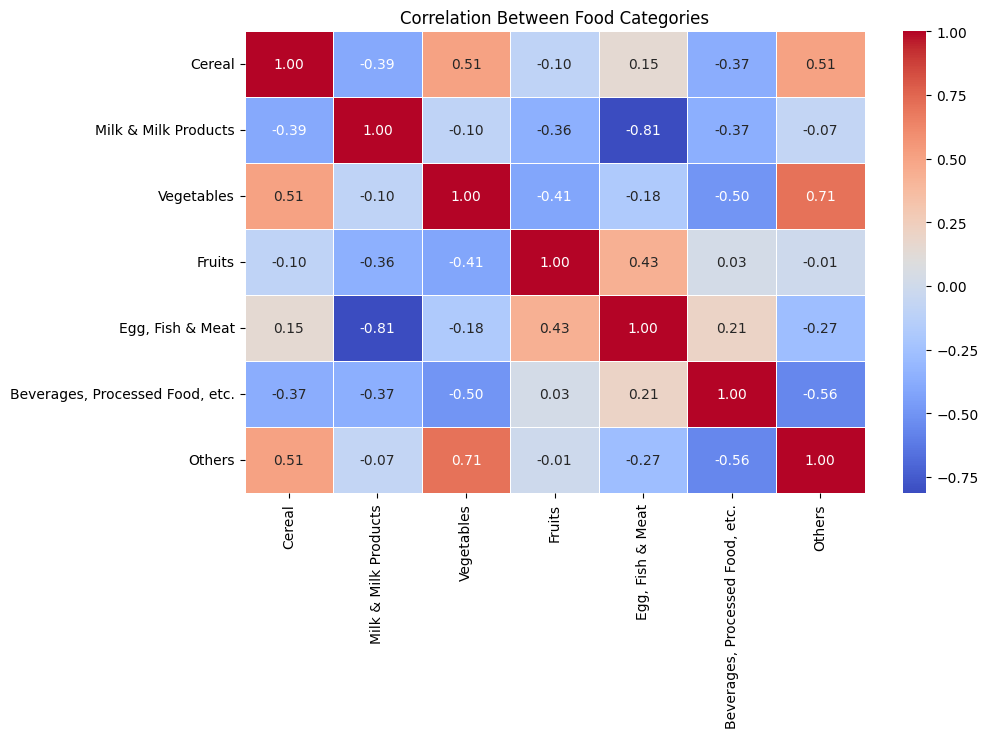

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Creating the DataFrame
data = {
    "State": [
        "Andhra Pradesh", "Assam", "Bihar", "Chhattisgarh", "Gujarat", "Haryana",
        "Jharkhand", "Karnataka", "Kerala", "Madhya Pradesh", "Maharashtra",
        "Odisha", "Punjab", "Rajasthan", "Tamil Nadu", "Telangana",
        "Uttar Pradesh", "West Bengal"
    ],
    "Cereal": [10.07, 9.08, 11.81, 11.03, 8.79, 6.67, 14.29, 9.55, 8.12, 10.50, 10.59, 12.89, 6.96, 10.39, 8.82, 9.99, 8.90, 11.42],
    "Milk & Milk Products": [15.21, 9.41, 19.66, 13.62, 21.21, 33.88, 16.40, 12.05, 9.49, 23.09, 16.06, 9.51, 29.02, 32.28, 11.36, 13.20, 25.49, 9.44],
    "Vegetables": [9.85, 11.06, 11.48, 17.16, 10.97, 11.07, 12.64, 8.49, 8.27, 11.60, 9.96, 14.17, 9.91, 9.93, 9.52, 8.46, 10.89, 12.67],
    "Fruits": [11.39, 9.14, 9.15, 10.19, 7.91, 8.78, 8.74, 11.07, 12.41, 9.67, 11.39, 7.90, 7.61, 9.28, 9.84, 10.36, 9.15, 8.19],
    "Egg, Fish & Meat": [12.61, 15.35, 9.60, 6.19, 1.85, 2.45, 8.71, 10.40, 21.30, 3.93, 7.37, 9.82, 2.58, 2.25, 12.66, 11.82, 5.37, 18.78],
    "Beverages, Processed Food, etc.": [25.72, 33.03, 21.98, 20.49, 31.48, 23.73, 21.18, 33.23, 25.19, 22.61, 28.12, 28.58, 30.72, 21.52, 34.30, 33.63, 22.94, 24.47],
    "Others": [15.15, 12.93, 16.31, 21.32, 17.79, 13.41, 18.04, 15.20, 15.22, 18.61, 16.52, 17.13, 13.20, 14.34, 13.50, 12.53, 17.25, 15.04]
}

df = pd.DataFrame(data)

### 1️⃣ Stacked Bar Chart: Food Category Distribution ###
df.set_index("State").plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab10")
plt.title("State-wise Food Category Distribution")
plt.ylabel("Percentage of Total Food Expenditure")
plt.xticks(rotation=90)
plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.show()

### 2️⃣ K-Means Clustering: Finding Similar State Groups ###
features = df.drop(columns=["State"])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_features)

# Scatter plot of two principal food categories (Cereal vs. Processed Food)
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["Cereal"], y=df["Beverages, Processed Food, etc."], hue=df["Cluster"], palette="Set1", s=100)
plt.title("Clustering of States Based on Food Expenditure")
plt.xlabel("Cereal Expenditure (%)")
plt.ylabel("Processed Food Expenditure (%)")
for i, txt in enumerate(df["State"]):
    plt.annotate(txt, (df["Cereal"][i], df["Beverages, Processed Food, etc."][i]), fontsize=8)
plt.legend(title="Cluster")
plt.show()

### 3️⃣ Heatmap: Correlation Between Food Categories ###
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=["State", "Cluster"]).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Food Categories")
plt.show()


# Table 3.10R: Percentage share of expenditure of non-food items in total non-food expenditure in 2023-24, major states - Rural

In [68]:
import plotly.express as px
rural_data = {
    "State": ["Andhra Pradesh", "Assam", "Bihar", "Chhattisgarh", "Gujarat", "Haryana", "Jharkhand", "Karnataka",
              "Kerala", "Madhya Pradesh", "Maharashtra", "Odisha", "Punjab", "Rajasthan", "Tamil Nadu", "Telangana",
              "Uttar Pradesh", "West Bengal"],
    "Fuel & Light": [9.73, 13.73, 12.00, 13.56, 13.38, 11.68, 14.84, 9.93, 9.70, 8.68, 11.86, 14.96, 14.22, 12.61, 8.26, 7.46, 11.79, 14.69],
    "Conveyance": [16.52, 12.72, 10.24, 15.08, 16.36, 14.57, 12.56, 15.56, 19.06, 15.66, 16.23, 12.76, 16.44, 15.27, 18.96, 14.23, 13.10, 8.71],
    "Education": [5.54, 3.93, 6.76, 1.92, 3.81, 9.20, 5.63, 5.40, 3.68, 5.85, 5.96, 5.12, 7.33, 6.33, 5.90, 5.95, 7.19, 6.81],
    "Medical": [15.17, 7.57, 14.13, 9.74, 12.37, 11.53, 12.03, 11.05, 17.33, 11.67, 14.03, 13.10, 14.87, 10.35, 11.93, 12.20, 13.75, 16.17],
    "Misc. Goods & Entertainment": [12.96, 13.18, 13.18, 12.37, 11.47, 10.69, 10.90, 13.45, 9.17, 11.15, 10.72, 13.63, 11.11, 9.83, 12.21, 10.80, 11.30, 12.76],
    "Clothing, Bedding & Footwear": [10.00, 15.07, 13.50, 14.59, 13.53, 12.96, 13.46, 10.14, 8.71, 13.66, 11.46, 14.42, 12.28, 12.09, 9.63, 12.59, 13.02, 14.52],
    "Durable Goods": [12.45, 10.14, 12.03, 9.44, 11.64, 12.47, 12.56, 14.25, 17.66, 11.54, 11.76, 9.13, 9.63, 15.76, 12.62, 13.46, 11.70, 9.93],
    "Others": [17.64, 23.66, 18.16, 23.31, 17.44, 16.90, 18.04, 20.22, 14.69, 21.80, 17.98, 16.89, 14.13, 17.76, 20.49, 23.31, 18.15, 16.41]
}

df_rural = pd.DataFrame(rural_data)

In [70]:
import plotly.express as px
fig = px.bar(df_rural.melt(id_vars=["State"]), x="State", y="value", color="variable",
             title="Rural Non-Food Expenditure Distribution", barmode="stack")
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

# Table 3.10U: Percentage share of expenditure of non-food items in total non-food expenditure in 2023-24, major states - Urban


In [71]:
urban_data = {
    "State": ["Andhra Pradesh", "Assam", "Bihar", "Chhattisgarh", "Gujarat", "Haryana", "Jharkhand", "Karnataka",
              "Kerala", "Madhya Pradesh", "Maharashtra", "Odisha", "Punjab", "Rajasthan", "Tamil Nadu", "Telangana",
              "Uttar Pradesh", "West Bengal"],
    "Fuel & Light": [8.20, 9.51, 11.11, 10.97, 10.98, 9.89, 10.45, 6.85, 8.42, 8.86, 9.92, 10.31, 12.80, 11.38, 6.62, 5.21, 11.49, 12.12],
    "Conveyance": [13.91, 14.22, 10.89, 15.19, 16.64, 13.82, 13.55, 13.38, 16.50, 14.97, 12.78, 14.11, 14.57, 15.56, 16.14, 13.25, 13.00, 10.15],
    "Education": [9.26, 6.08, 10.42, 7.45, 11.05, 7.88, 10.77, 10.10, 6.71, 11.07, 10.83, 6.05, 9.48, 12.14, 9.44, 12.79, 10.40, 10.32],
    "Medical": [10.41, 7.78, 11.60, 9.81, 9.28, 7.30, 8.93, 8.00, 14.42, 9.40, 9.63, 7.99, 12.75, 8.26, 9.46, 7.65, 10.60, 14.84],
    "Misc. Goods & Entertainment": [11.67, 13.42, 13.25, 12.41, 12.41, 11.86, 12.07, 11.62, 8.90, 12.77, 10.92, 12.44, 12.26, 9.65, 10.80, 10.67, 12.75, 12.18],
    "Clothing, Bedding & Footwear": [8.36, 11.33, 11.58, 11.33, 10.19, 11.96, 11.71, 7.43, 7.47, 10.53, 8.43, 12.12, 12.26, 9.99, 7.38, 7.50, 10.97, 11.52],
    "Durable Goods": [12.33, 10.27, 12.16, 8.99, 8.61, 9.72, 11.37, 10.08, 17.97, 12.10, 9.57, 12.45, 8.62, 12.86, 12.13, 10.82, 11.22, 9.87],
    "Others": [25.87, 27.39, 18.99, 23.86, 20.83, 27.58, 21.15, 32.54, 19.61, 20.31, 27.92, 24.53, 17.27, 20.14, 28.04, 32.11, 19.59, 18.99]
}

df_urban = pd.DataFrame(urban_data)

In [72]:

fig = px.bar(df_urban.melt(id_vars=["State"]), x="State", y="value", color="variable",
             title="Urban Non-Food Expenditure Distribution", barmode="stack")
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

# Table 3.12: Average MPCE (Rs.) by social group in 2023-24, major states

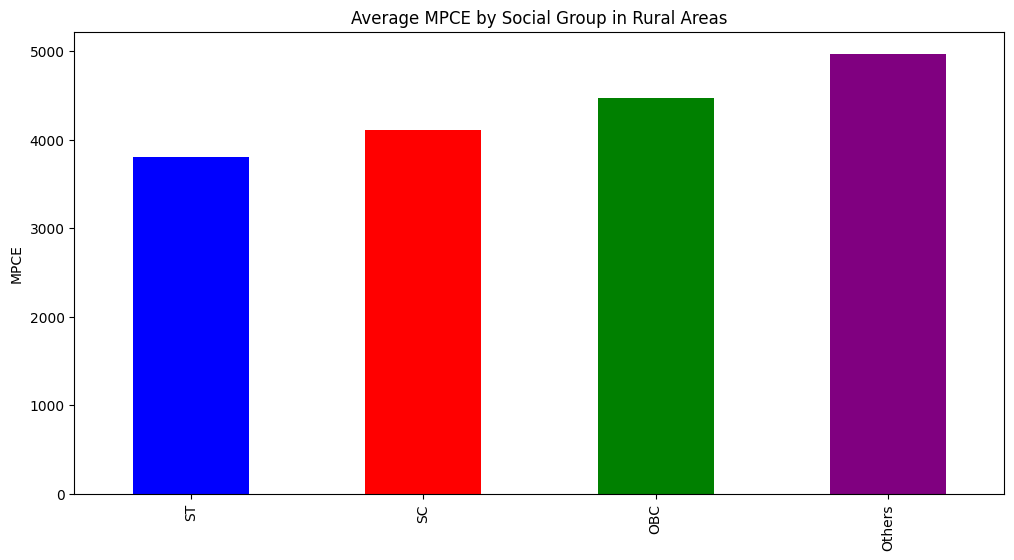

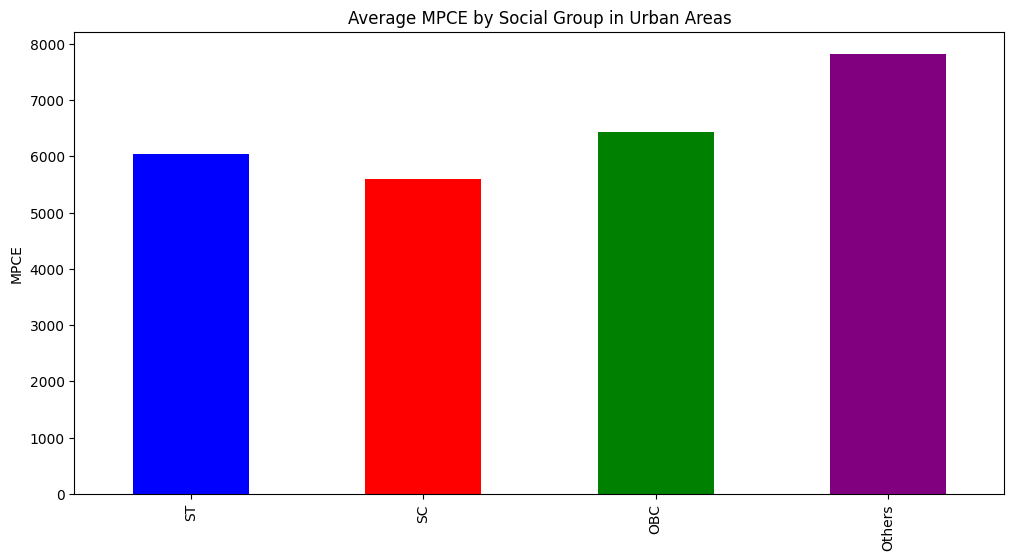

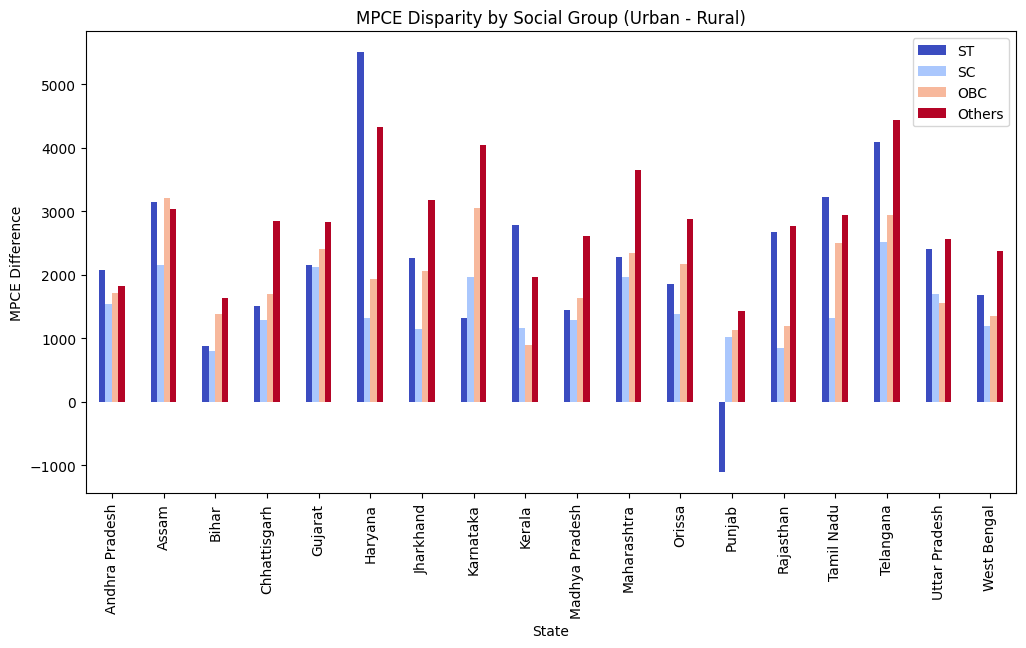

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Creating DataFrame for Rural Household Consumption Expenditure
data_rural = {
    "State": ["Andhra Pradesh", "Assam", "Bihar", "Chhattisgarh", "Gujarat", "Haryana", "Jharkhand", "Karnataka",
              "Kerala", "Madhya Pradesh", "Maharashtra", "Orissa", "Punjab", "Rajasthan", "Tamil Nadu", "Telangana",
              "Uttar Pradesh", "West Bengal"],
    "ST": [4162, 3774, 3334, 2471, 3690, 5688, 2497, 4590, 4908, 3004, 3103, 2800, 5150, 3384, 4831, 4981, 2980, 3077],
    "SC": [5145, 3758, 3374, 3047, 3825, 4756, 2827, 4620, 5449, 3416, 3986, 3235, 5136, 4196, 5340, 5162, 3219, 3507],
    "OBC": [5384, 3823, 3733, 2902, 4008, 5529, 3260, 4926, 6262, 3582, 4242, 3618, 5921, 4854, 5835, 5482, 3480, 3630],
    "Others": [5715, 3785, 4017, 3329, 5137, 5786, 3361, 5566, 7738, 3964, 4599, 3924, 6867, 5238, 6202, 6449, 3955, 3791],
    "All": [5327, 3793, 3670, 2739, 4116, 5377, 2946, 4903, 6611, 3441, 4145, 3357, 5817, 4510, 5701, 5435, 3481, 3620]
}

df_rural = pd.DataFrame(data_rural)

# Creating DataFrame for Urban Household Consumption Expenditure
data_urban = {
    "State": ["Andhra Pradesh", "Assam", "Bihar", "Chhattisgarh", "Gujarat", "Haryana", "Jharkhand", "Karnataka",
              "Kerala", "Madhya Pradesh", "Maharashtra", "Orissa", "Punjab", "Rajasthan", "Tamil Nadu", "Telangana",
              "Uttar Pradesh", "West Bengal"],
    "ST": [6244, 6914, 4208, 3988, 5837, 11188, 4761, 5908, 7688, 4445, 5377, 4650, 4039, 6065, 8050, 9065, 5383, 4761],
    "SC": [6686, 5918, 4174, 4337, 5955, 6080, 3969, 6584, 6609, 4711, 5956, 4611, 6160, 5050, 6662, 7680, 4918, 4704],
    "OBC": [7102, 7026, 5120, 4596, 6415, 7465, 5321, 7971, 7165, 5221, 6580, 5785, 7054, 6051, 8338, 8421, 5030, 4976],
    "Others": [7543, 6825, 5650, 6179, 7971, 10113, 6543, 9614, 9708, 6571, 8250, 6807, 8290, 8011, 9139, 10893, 6522, 6173],
    "All": [7182, 6794, 5080, 4927, 7175, 8427, 5393, 8076, 7783, 5538, 7363, 5825, 7359, 6574, 8165, 8978, 5395, 5775]
}

df_urban = pd.DataFrame(data_urban)

# Social Group-Wise MPCE Comparison
fig, ax = plt.subplots(figsize=(12, 6))
df_rural.set_index("State")[["ST", "SC", "OBC", "Others"]].mean().plot(kind='bar', ax=ax, color=['blue', 'red', 'green', 'purple'])
plt.title("Average MPCE by Social Group in Rural Areas")
plt.ylabel("MPCE")
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
df_urban.set_index("State")[["ST", "SC", "OBC", "Others"]].mean().plot(kind='bar', ax=ax, color=['blue', 'red', 'green', 'purple'])
plt.title("Average MPCE by Social Group in Urban Areas")
plt.ylabel("MPCE")
plt.show()

# Social Group Disparity Analysis
disparity = (df_urban.set_index("State") - df_rural.set_index("State"))
disparity[["ST", "SC", "OBC", "Others"]].plot(kind='bar', figsize=(12, 6), colormap='coolwarm')
plt.title("MPCE Disparity by Social Group (Urban - Rural)")
plt.ylabel("MPCE Difference")
plt.xticks(rotation=90)
plt.show()


# Table 3.16: Gini coefficient of total consumption expenditure in 2023-24, major states

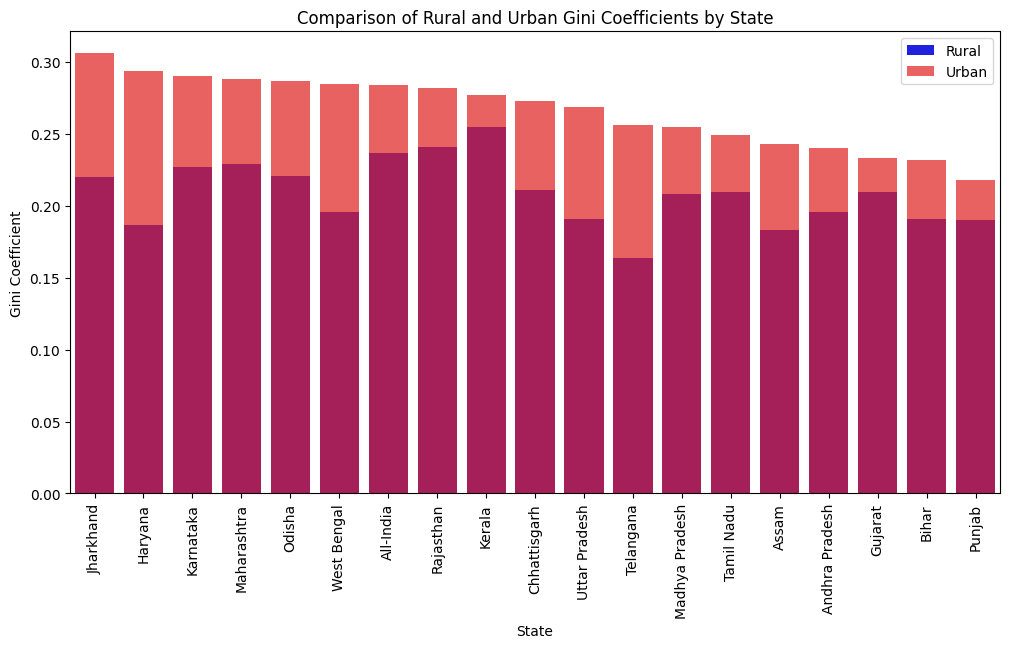

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\3634063106.py:40: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




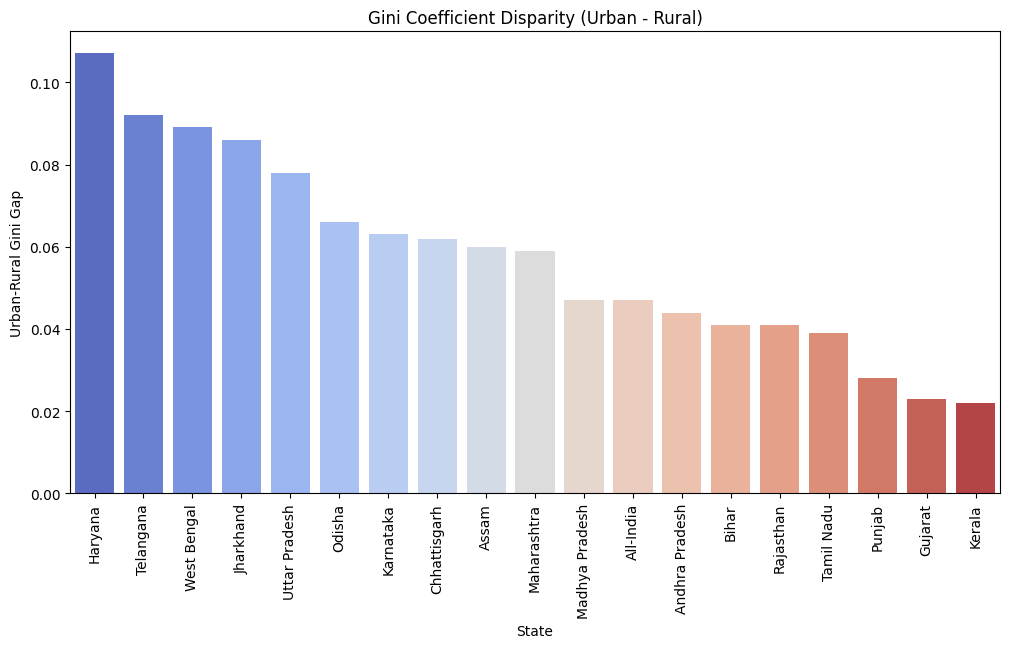

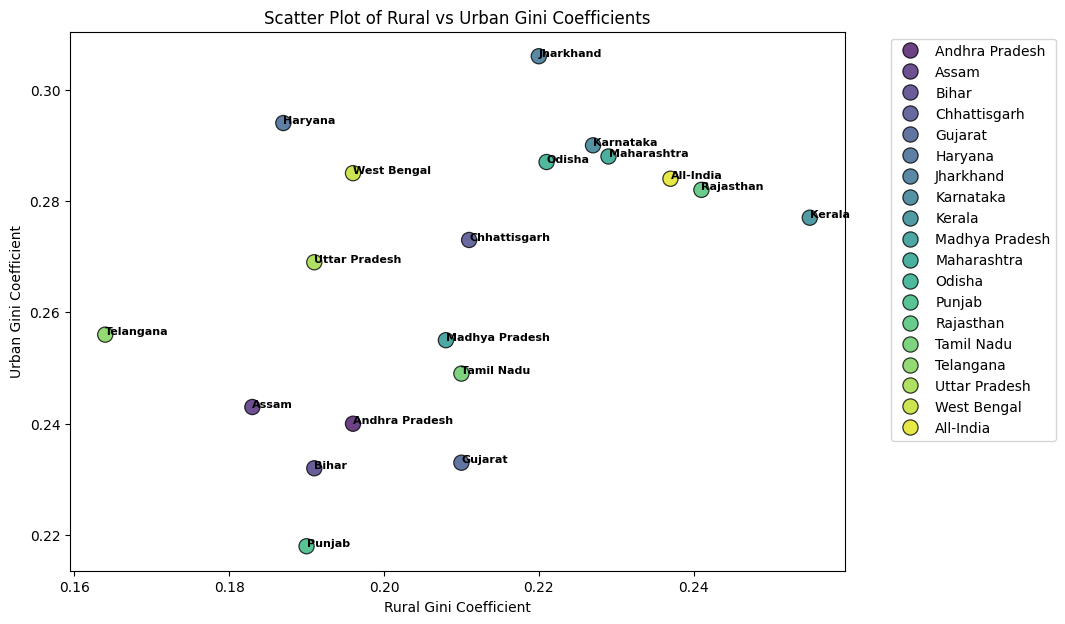

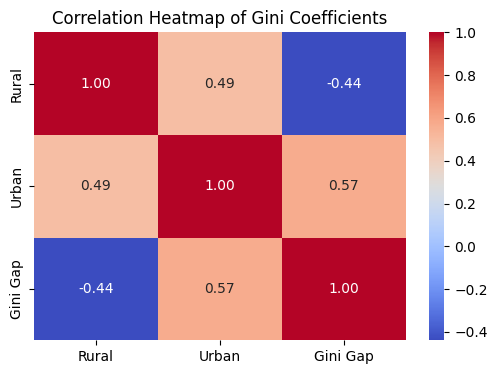

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Creating DataFrame
data_gini = {
    "Major State": [
        "Andhra Pradesh", "Assam", "Bihar", "Chhattisgarh", "Gujarat", "Haryana", "Jharkhand", "Karnataka",
        "Kerala", "Madhya Pradesh", "Maharashtra", "Odisha", "Punjab", "Rajasthan", "Tamil Nadu", "Telangana",
        "Uttar Pradesh", "West Bengal", "All-India"
    ],
    "Rural": [0.196, 0.183, 0.191, 0.211, 0.210, 0.187, 0.220, 0.227, 0.255, 0.208, 0.229, 0.221, 0.190, 0.241, 0.210, 0.164, 0.191, 0.196, 0.237],
    "Urban": [0.240, 0.243, 0.232, 0.273, 0.233, 0.294, 0.306, 0.290, 0.277, 0.255, 0.288, 0.287, 0.218, 0.282, 0.249, 0.256, 0.269, 0.285, 0.284]
}

df_gini = pd.DataFrame(data_gini)

# Calculate Urban-Rural Gini Gap
df_gini["Gini Gap"] = df_gini["Urban"] - df_gini["Rural"]

def plot_gini_bar_chart(df):
    df_sorted = df.sort_values(by="Urban", ascending=False)
    plt.figure(figsize=(12, 6))
    
    sns.barplot(x=df_sorted["Major State"], y=df_sorted["Rural"], color='blue', label='Rural')
    sns.barplot(x=df_sorted["Major State"], y=df_sorted["Urban"], color='red', alpha=0.7, label='Urban')
    
    plt.xticks(rotation=90)
    plt.xlabel("State")
    plt.ylabel("Gini Coefficient")
    plt.title("Comparison of Rural and Urban Gini Coefficients by State")
    plt.legend()
    plt.show()


def plot_gini_gap(df):
    df_sorted = df.sort_values(by="Gini Gap", ascending=False)
    plt.figure(figsize=(12, 6))
    
    sns.barplot(x=df_sorted["Major State"], y=df_sorted["Gini Gap"], palette="coolwarm")
    
    plt.xticks(rotation=90)
    plt.xlabel("State")
    plt.ylabel("Urban-Rural Gini Gap")
    plt.title("Gini Coefficient Disparity (Urban - Rural)")
    plt.show()


def plot_scatter_gini(df):
    plt.figure(figsize=(10, 7))
    scatter = sns.scatterplot(x="Rural", y="Urban", hue="Major State", data=df, palette='viridis', s=120, edgecolor='black', alpha=0.8)
    
    for line in range(0, df.shape[0]):
        plt.text(df["Rural"][line], df["Urban"][line], df["Major State"][line], horizontalalignment='left', size=8, color='black', weight='semibold')
    
    plt.xlabel("Rural Gini Coefficient")
    plt.ylabel("Urban Gini Coefficient")
    plt.title("Scatter Plot of Rural vs Urban Gini Coefficients")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

def plot_heatmap(df):
    plt.figure(figsize=(6, 4))
    corr_matrix = df[["Rural", "Urban", "Gini Gap"]].corr()
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap of Gini Coefficients")
    plt.show()

# Execute visualizations
plot_gini_bar_chart(df_gini)
plot_gini_gap(df_gini)
plot_scatter_gini(df_gini)
plot_heatmap(df_gini)


C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\4131202079.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\4131202079.py:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\4131202079.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\4131202079.py:15: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



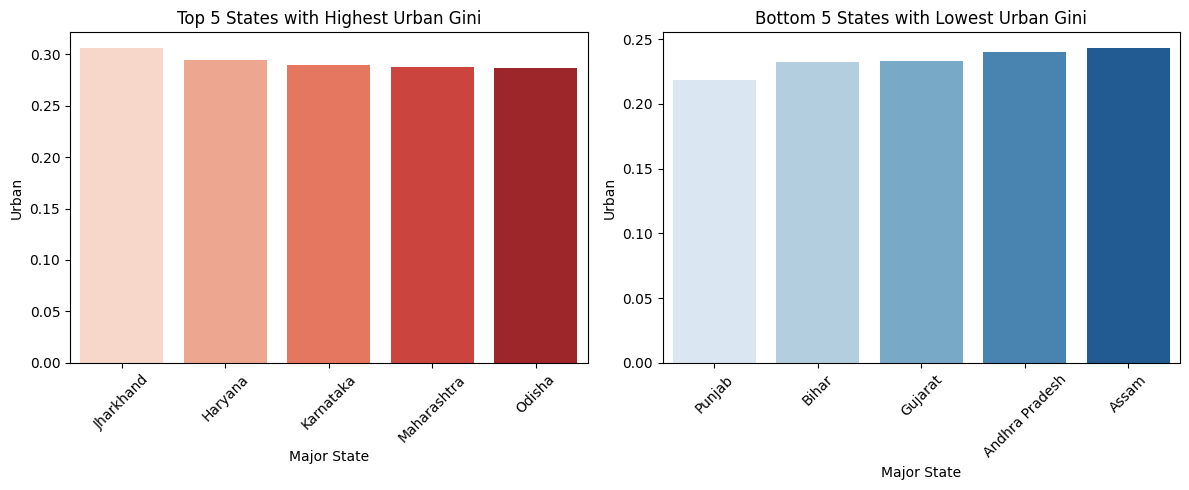

In [75]:
# Identify Top 5 and Bottom 5 states by Gini Coefficient
top_5 = df_gini.nlargest(5, "Urban")
bottom_5 = df_gini.nsmallest(5, "Urban")



def plot_top_bottom_gini(top_df, bottom_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.barplot(x="Major State", y="Urban", data=top_df, ax=axes[0], palette="Reds")
    axes[0].set_title("Top 5 States with Highest Urban Gini")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
    
    sns.barplot(x="Major State", y="Urban", data=bottom_df, ax=axes[1], palette="Blues")
    axes[1].set_title("Bottom 5 States with Lowest Urban Gini")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()



plot_top_bottom_gini(top_5, bottom_5)


# Table 3.21U: Average MPCE (Rs.) by household type in 2023-24, major states - Urban

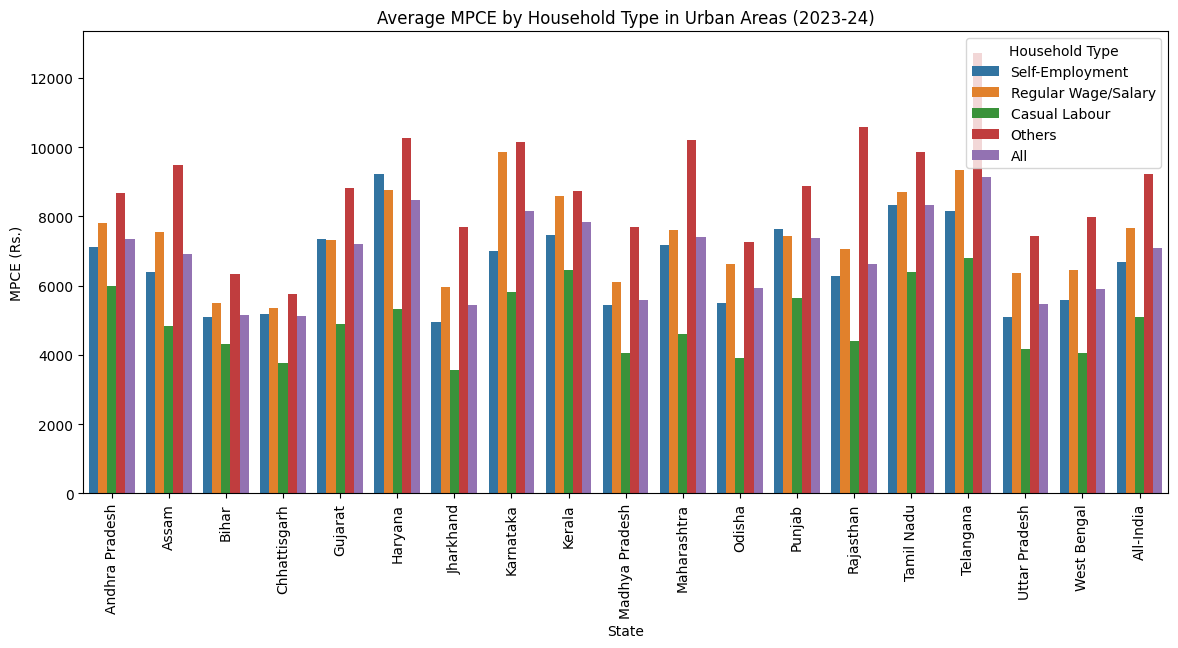

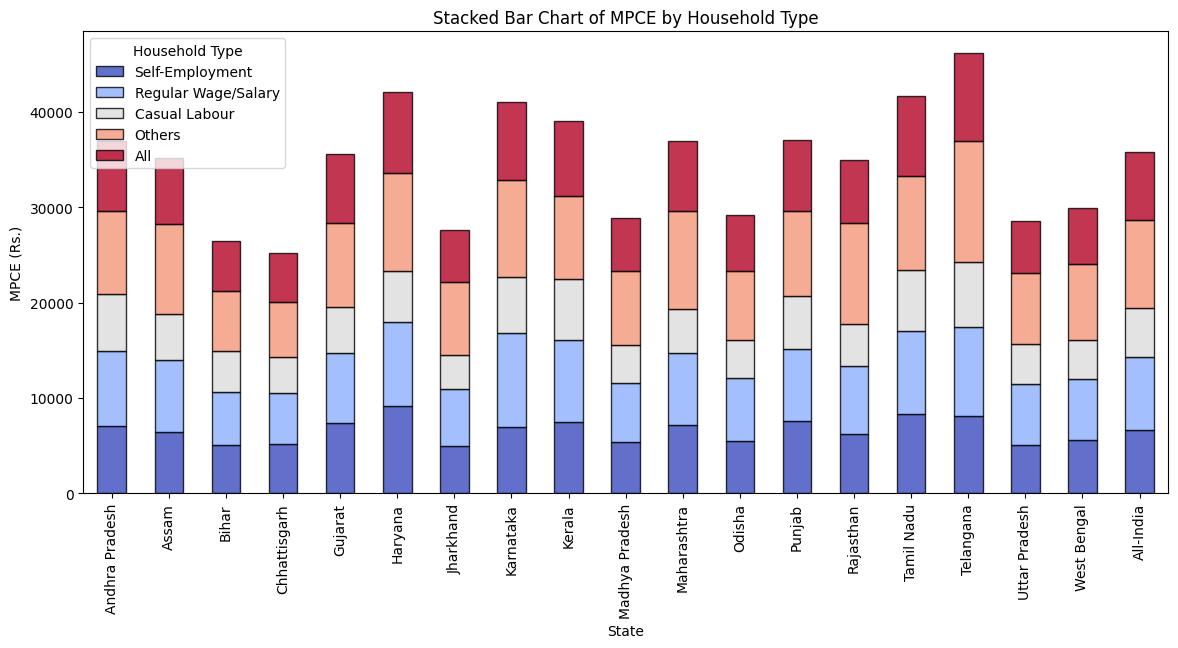

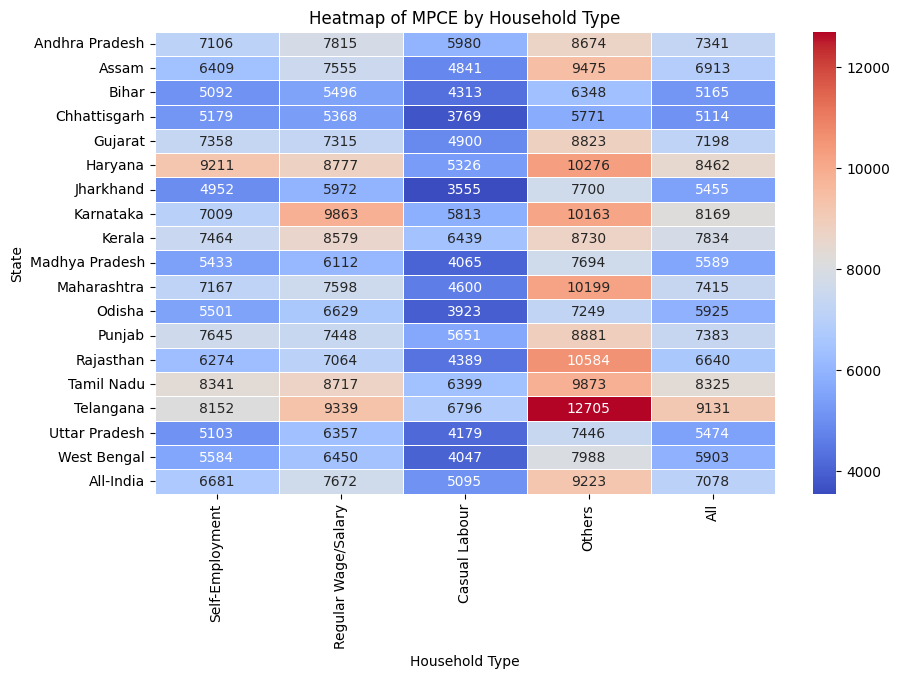

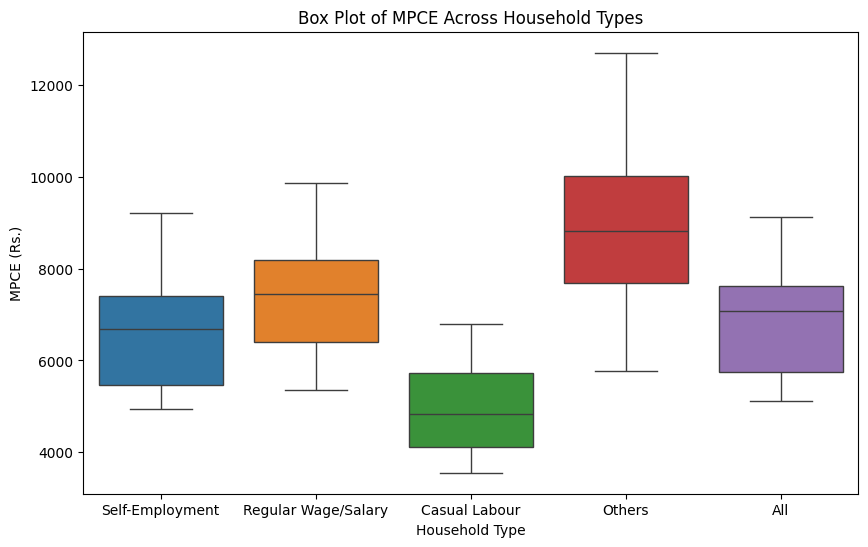

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\1387137595.py:62: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




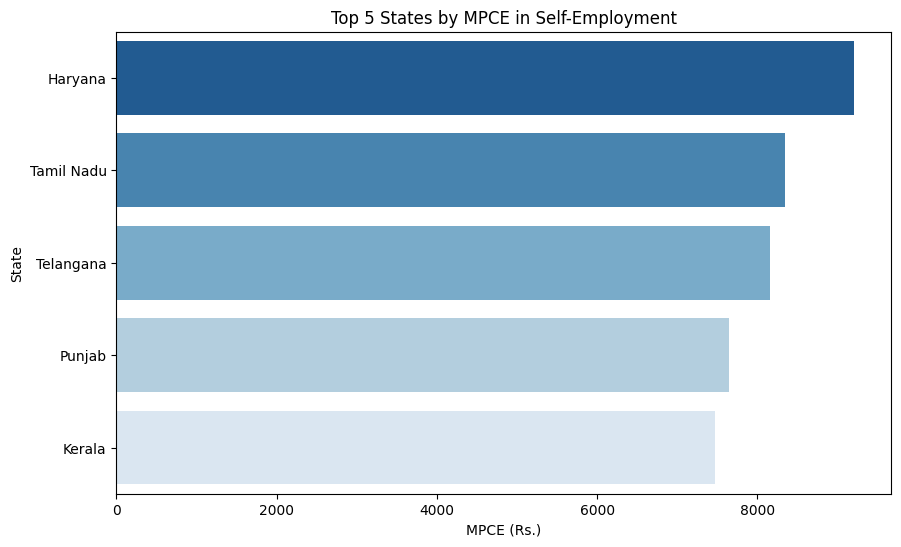

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\1387137595.py:69: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




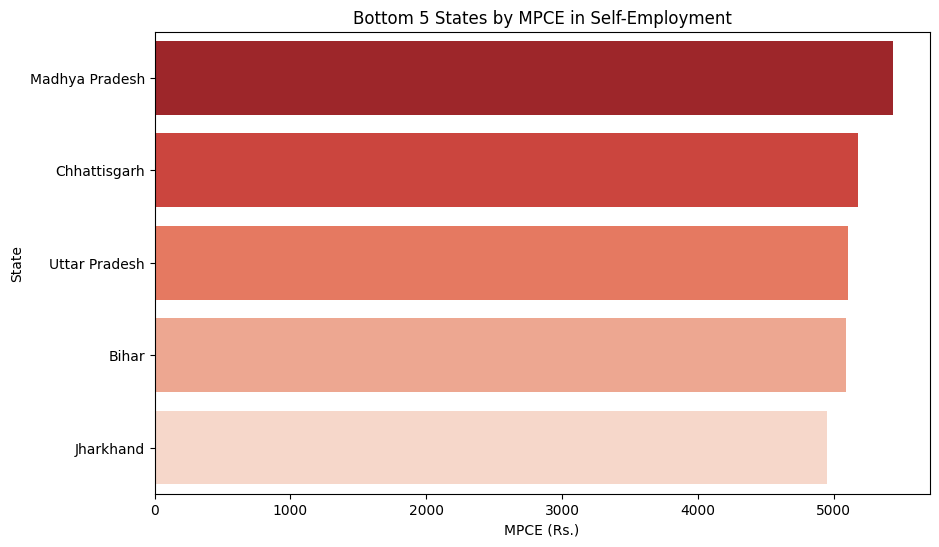

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\1387137595.py:62: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




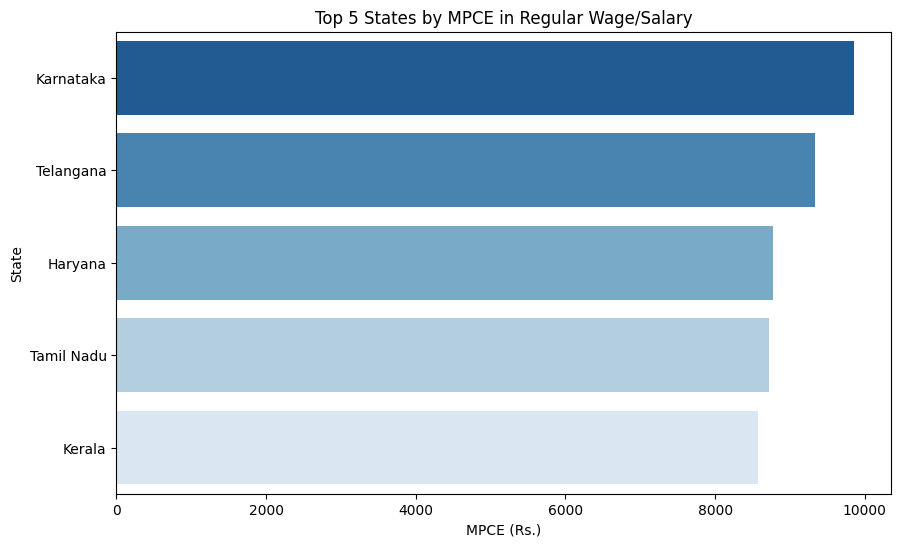

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\1387137595.py:69: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




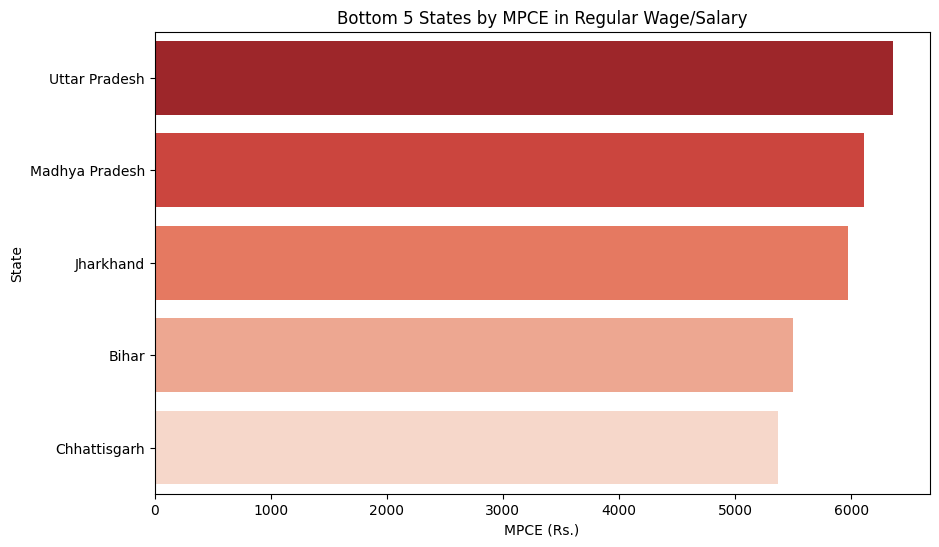

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\1387137595.py:62: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




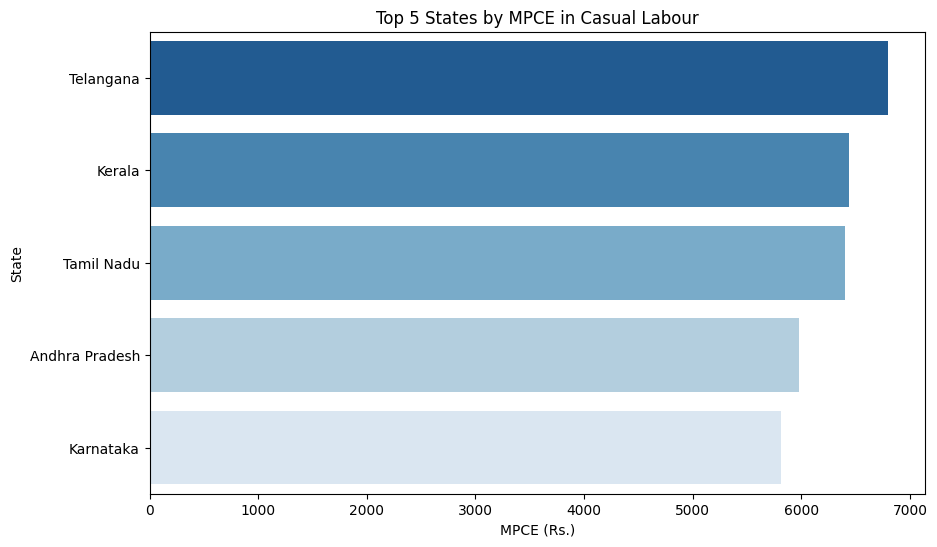

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\1387137595.py:69: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




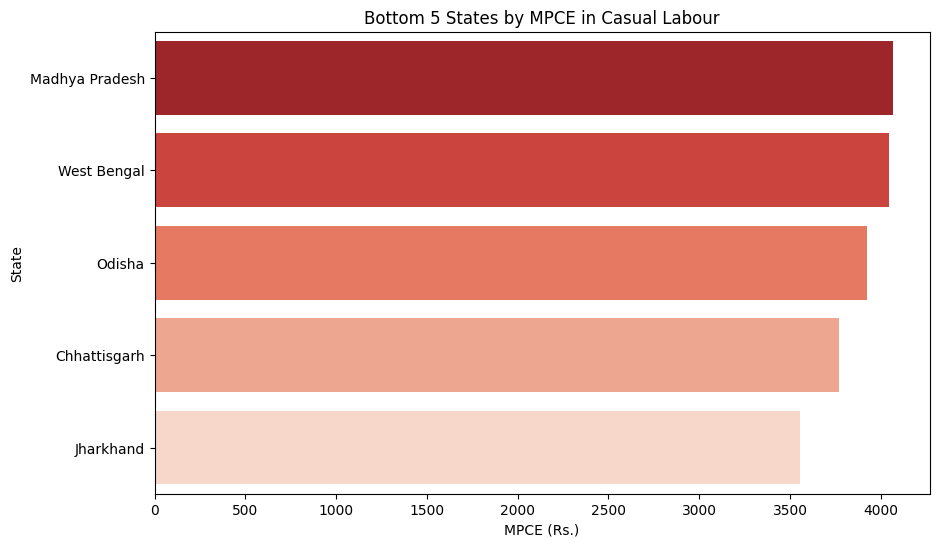

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\1387137595.py:62: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




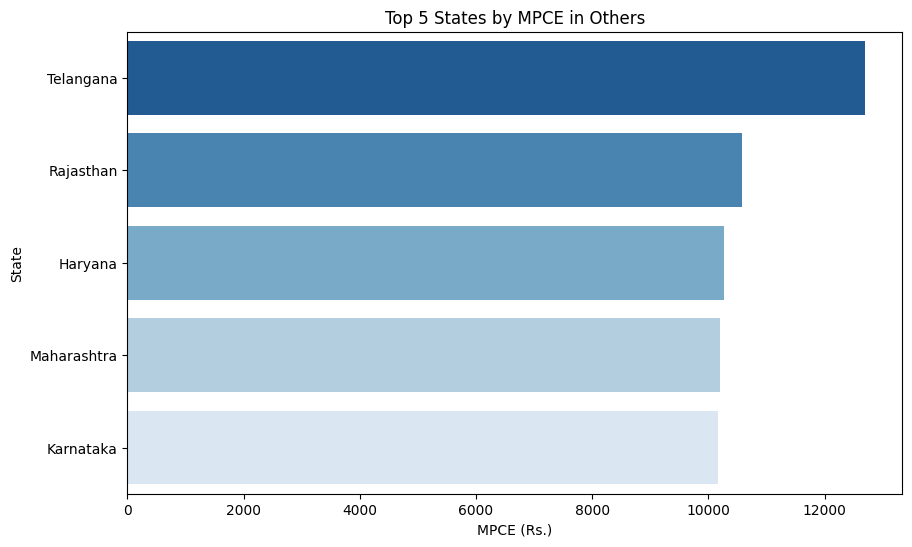

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\1387137595.py:69: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




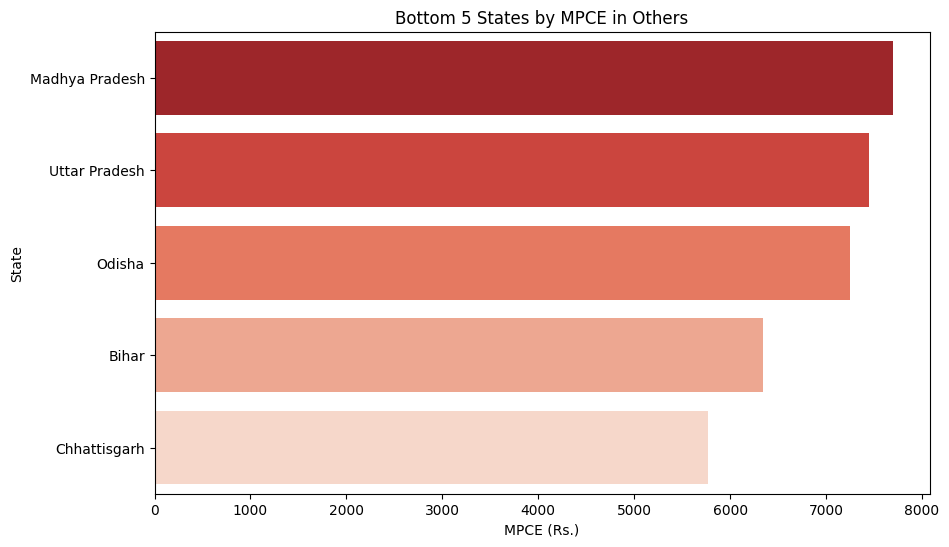

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\1387137595.py:62: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




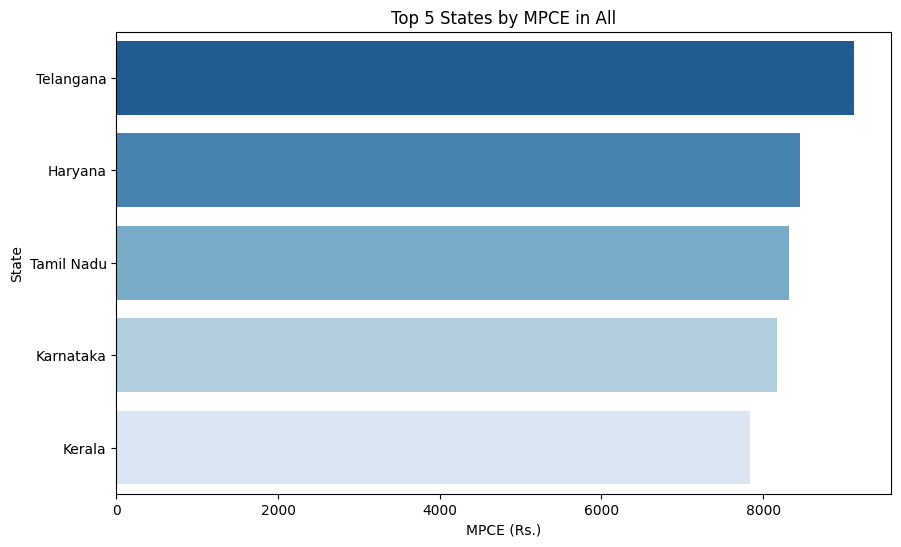

C:\Users\ayans\AppData\Local\Temp\ipykernel_12512\1387137595.py:69: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




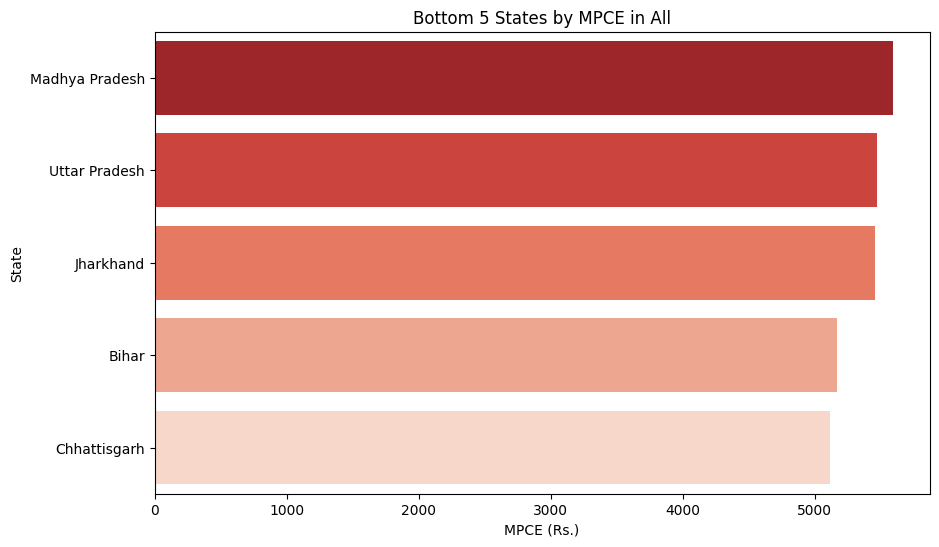

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Creating DataFrame for MPCE by household type in Urban areas
data_mpce = {
    "Major State": [
        "Andhra Pradesh", "Assam", "Bihar", "Chhattisgarh", "Gujarat", "Haryana", "Jharkhand", "Karnataka",
        "Kerala", "Madhya Pradesh", "Maharashtra", "Odisha", "Punjab", "Rajasthan", "Tamil Nadu", "Telangana",
        "Uttar Pradesh", "West Bengal", "All-India"
    ],
    "Self-Employment": [7106, 6409, 5092, 5179, 7358, 9211, 4952, 7009, 7464, 5433, 7167, 5501, 7645, 6274, 8341, 8152, 5103, 5584, 6681],
    "Regular Wage/Salary": [7815, 7555, 5496, 5368, 7315, 8777, 5972, 9863, 8579, 6112, 7598, 6629, 7448, 7064, 8717, 9339, 6357, 6450, 7672],
    "Casual Labour": [5980, 4841, 4313, 3769, 4900, 5326, 3555, 5813, 6439, 4065, 4600, 3923, 5651, 4389, 6399, 6796, 4179, 4047, 5095],
    "Others": [8674, 9475, 6348, 5771, 8823, 10276, 7700, 10163, 8730, 7694, 10199, 7249, 8881, 10584, 9873, 12705, 7446, 7988, 9223],
    "All": [7341, 6913, 5165, 5114, 7198, 8462, 5455, 8169, 7834, 5589, 7415, 5925, 7383, 6640, 8325, 9131, 5474, 5903, 7078]
}

df_mpce = pd.DataFrame(data_mpce)

# 1. Grouped Bar Chart
plt.figure(figsize=(14, 6))
df_mpce_melted = df_mpce.melt(id_vars=["Major State"], var_name="Household Type", value_name="MPCE")
sns.barplot(x="Major State", y="MPCE", hue="Household Type", data=df_mpce_melted)
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("MPCE (Rs.)")
plt.title("Average MPCE by Household Type in Urban Areas (2023-24)")
plt.legend(title="Household Type")
plt.show()

# 2. Stacked Bar Chart
df_mpce.set_index("Major State").plot(kind='bar', stacked=True, figsize=(14, 6), colormap='coolwarm', edgecolor='black', alpha=0.8)
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("MPCE (Rs.)")
plt.title("Stacked Bar Chart of MPCE by Household Type")
plt.legend(title="Household Type")
plt.show()

# 3. Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_mpce.set_index("Major State"), annot=True, fmt=".0f", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap of MPCE by Household Type")
plt.ylabel("State")
plt.xlabel("Household Type")
plt.show()

# 4. Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_mpce.drop(columns=["Major State"]))
plt.xlabel("Household Type")
plt.ylabel("MPCE (Rs.)")
plt.title("Box Plot of MPCE Across Household Types")
plt.show()

# Function to plot Top & Bottom 5 States for each category
def plot_top_bottom(df, category):
    df_sorted = df.sort_values(by=category, ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=category, y="Major State", data=df_sorted.head(5), palette="Blues_r")
    plt.xlabel("MPCE (Rs.)")
    plt.ylabel("State")
    plt.title(f"Top 5 States by MPCE in {category}")
    plt.show()
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=category, y="Major State", data=df_sorted.tail(5), palette="Reds_r")
    plt.xlabel("MPCE (Rs.)")
    plt.ylabel("State")
    plt.title(f"Bottom 5 States by MPCE in {category}")
    plt.show()

# Plot for each category
for category in ["Self-Employment", "Regular Wage/Salary", "Casual Labour", "Others", "All"]:
    plot_top_bottom(df_mpce, category)
